In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr, tree as jtu
from scipy.ndimage import binary_dilation
import dLux.utils as dlu

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl


import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
# plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

# Loading in data

In [2]:
dfnrnn_model = amigo.ramp_models.DFRNN(jr.key(0))
ramp_model = amigo.ramp_models.RNNRamp(
    dfnrnn_model, gain_model=amigo.detector_models.PixelSensitivity(), norm=2**14
)

model = amigo.core_models.AmigoModel(
    [],
    optics=amigo.optical_models.AMIOptics(),
    detector=None,
    read=None,
)

In [ ]:
god_given_osamp = 12

god_model = model.set("oversample", god_given_osamp)

FILTERS = [
    # "F380M",
    "F430M",
    # "F480M",
]

god_psfs = {}

for filter in FILTERS:

    print(f"Filter: {filter}")

    wavels, weights = god_model.filters[filter]

    god_psf_osamp = god_model.optics.propagate(wavels, weights=weights)
    god_psf = dlu.downsample(god_psf_osamp, god_given_osamp // 3)
    god_psf = 1e6 * god_psf * (god_given_osamp // 3) ** 2

    god_psfs[filter] = god_psf

Filter: F430M


Filter: F430M, Oversampling: 1
(240, 240) (240, 240) (240, 240)


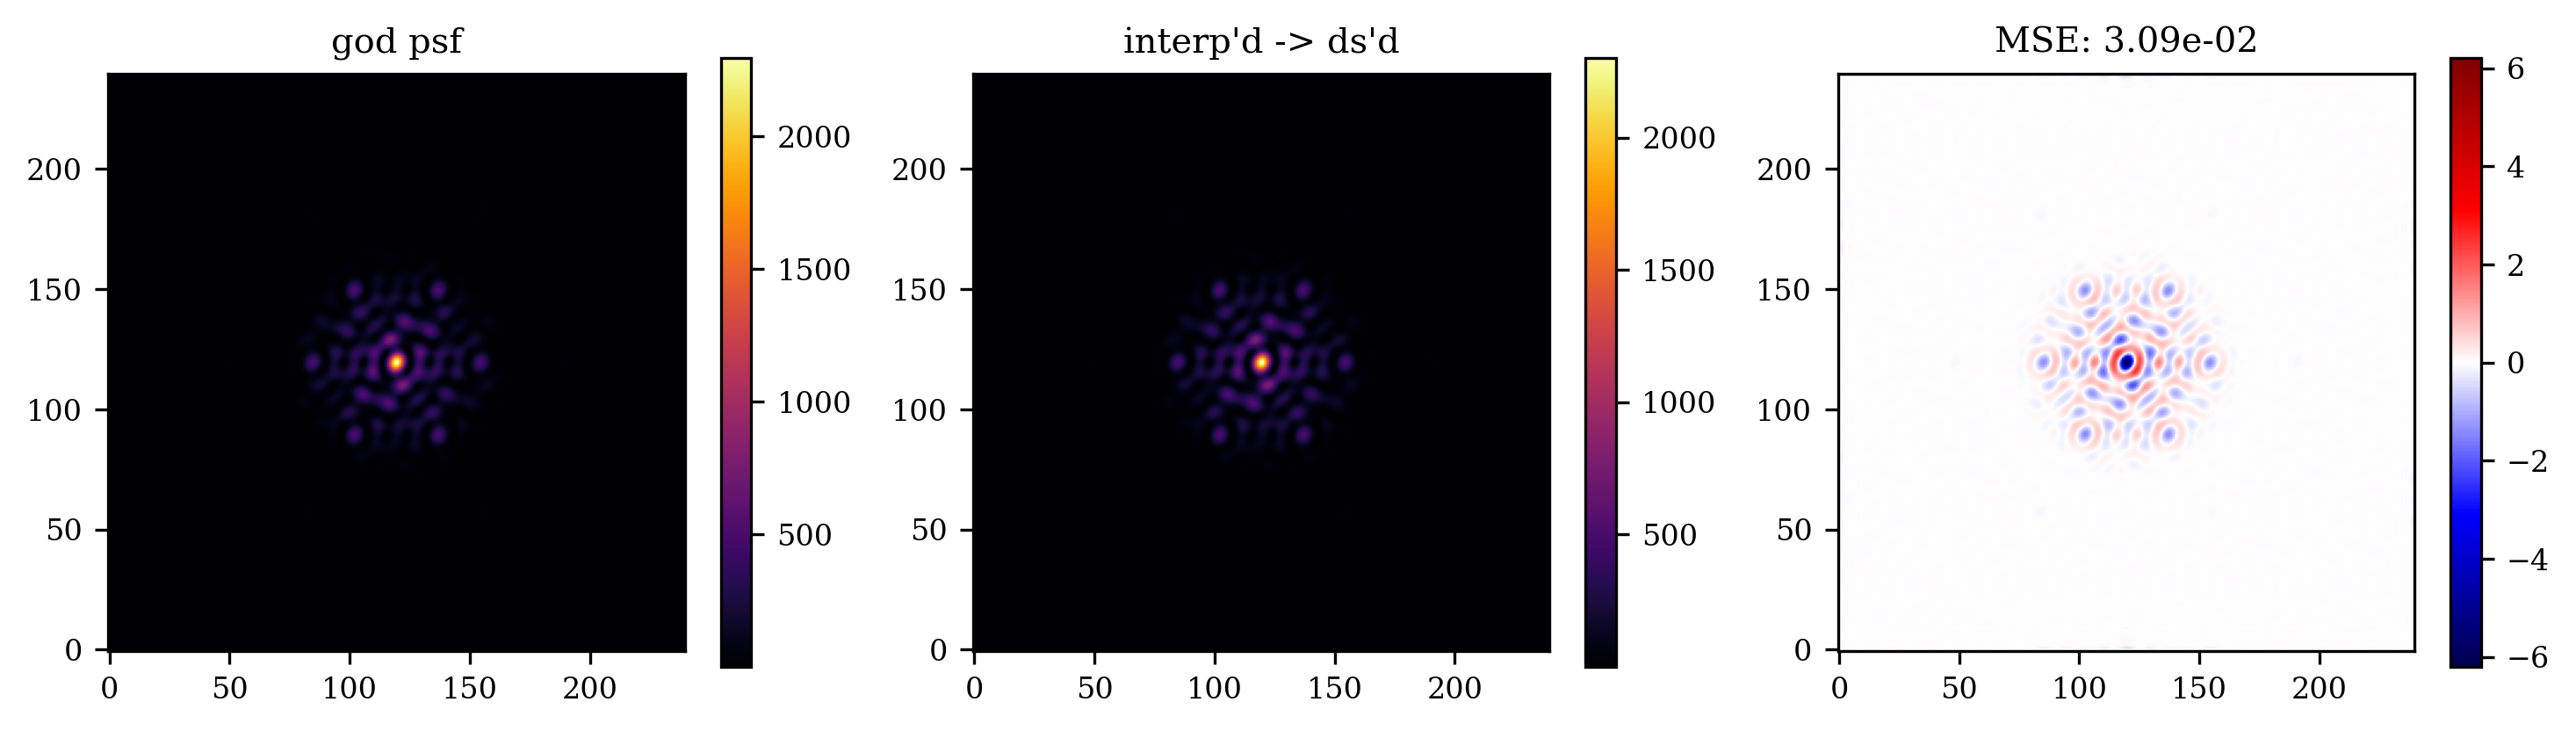

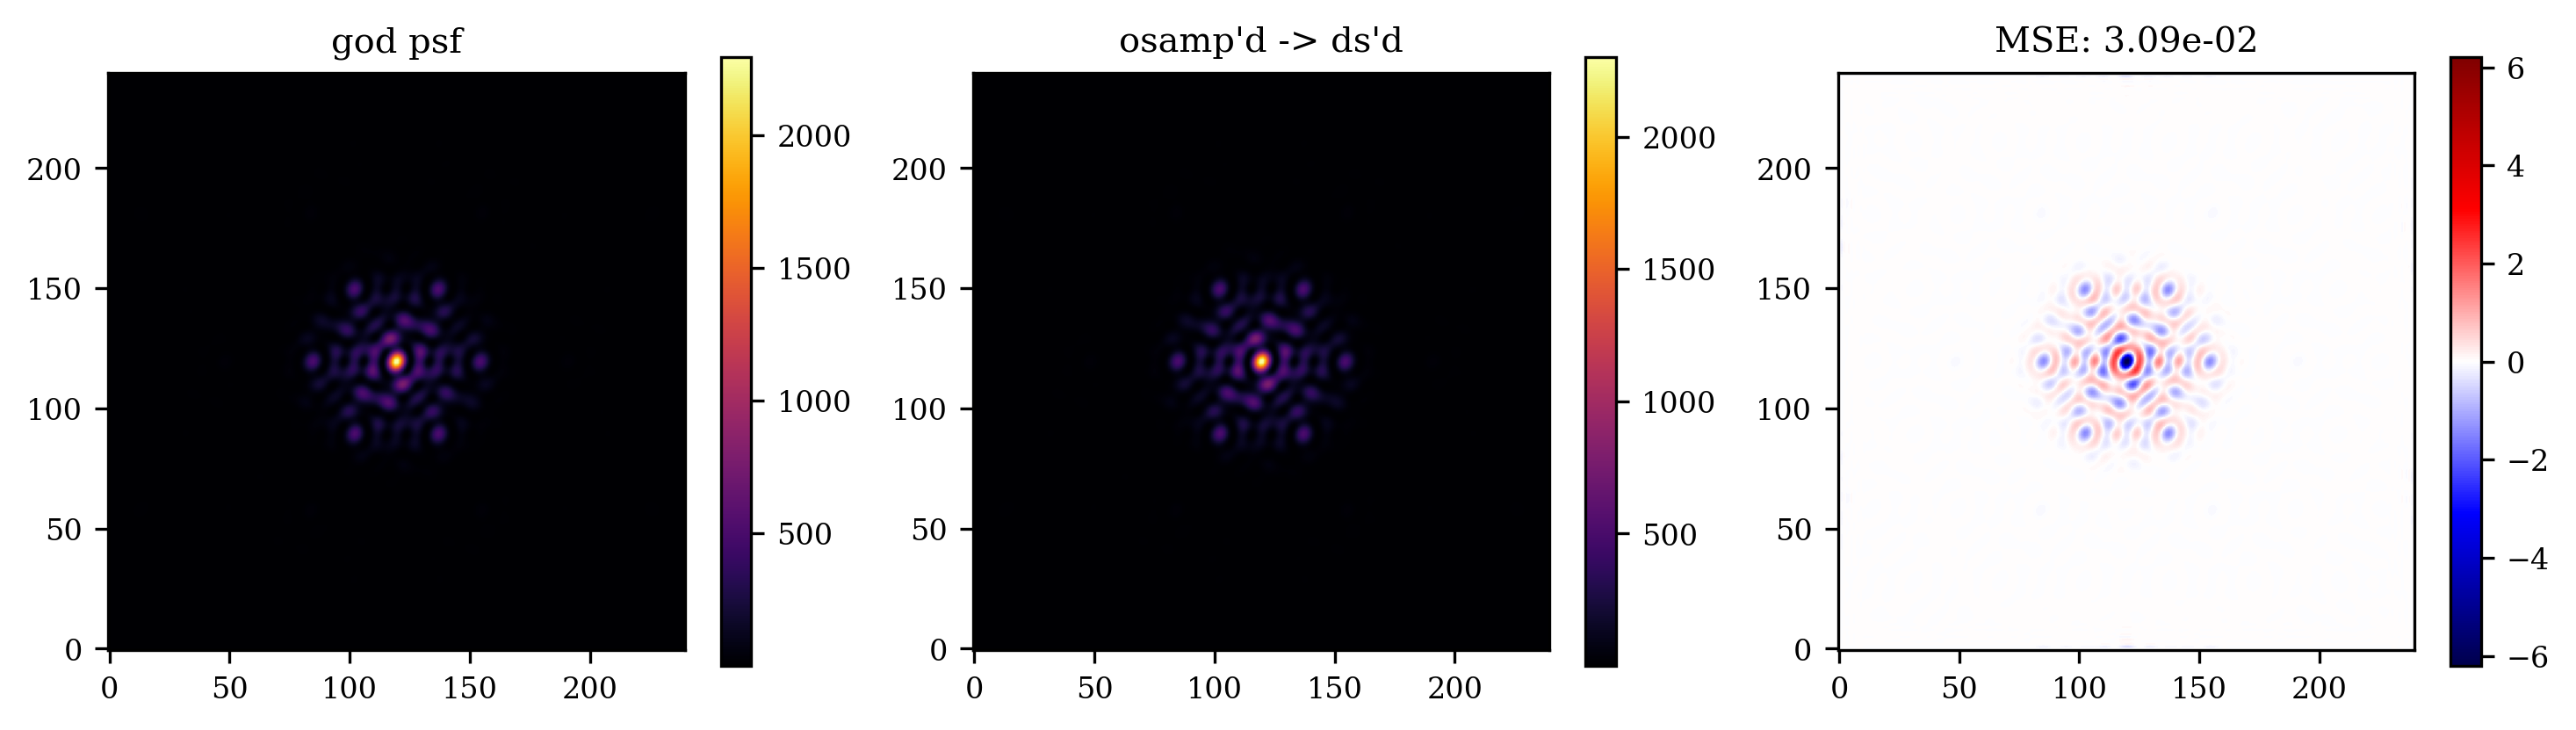

Filter: F430M, Oversampling: 2
(240, 240) (480, 480) (240, 240)


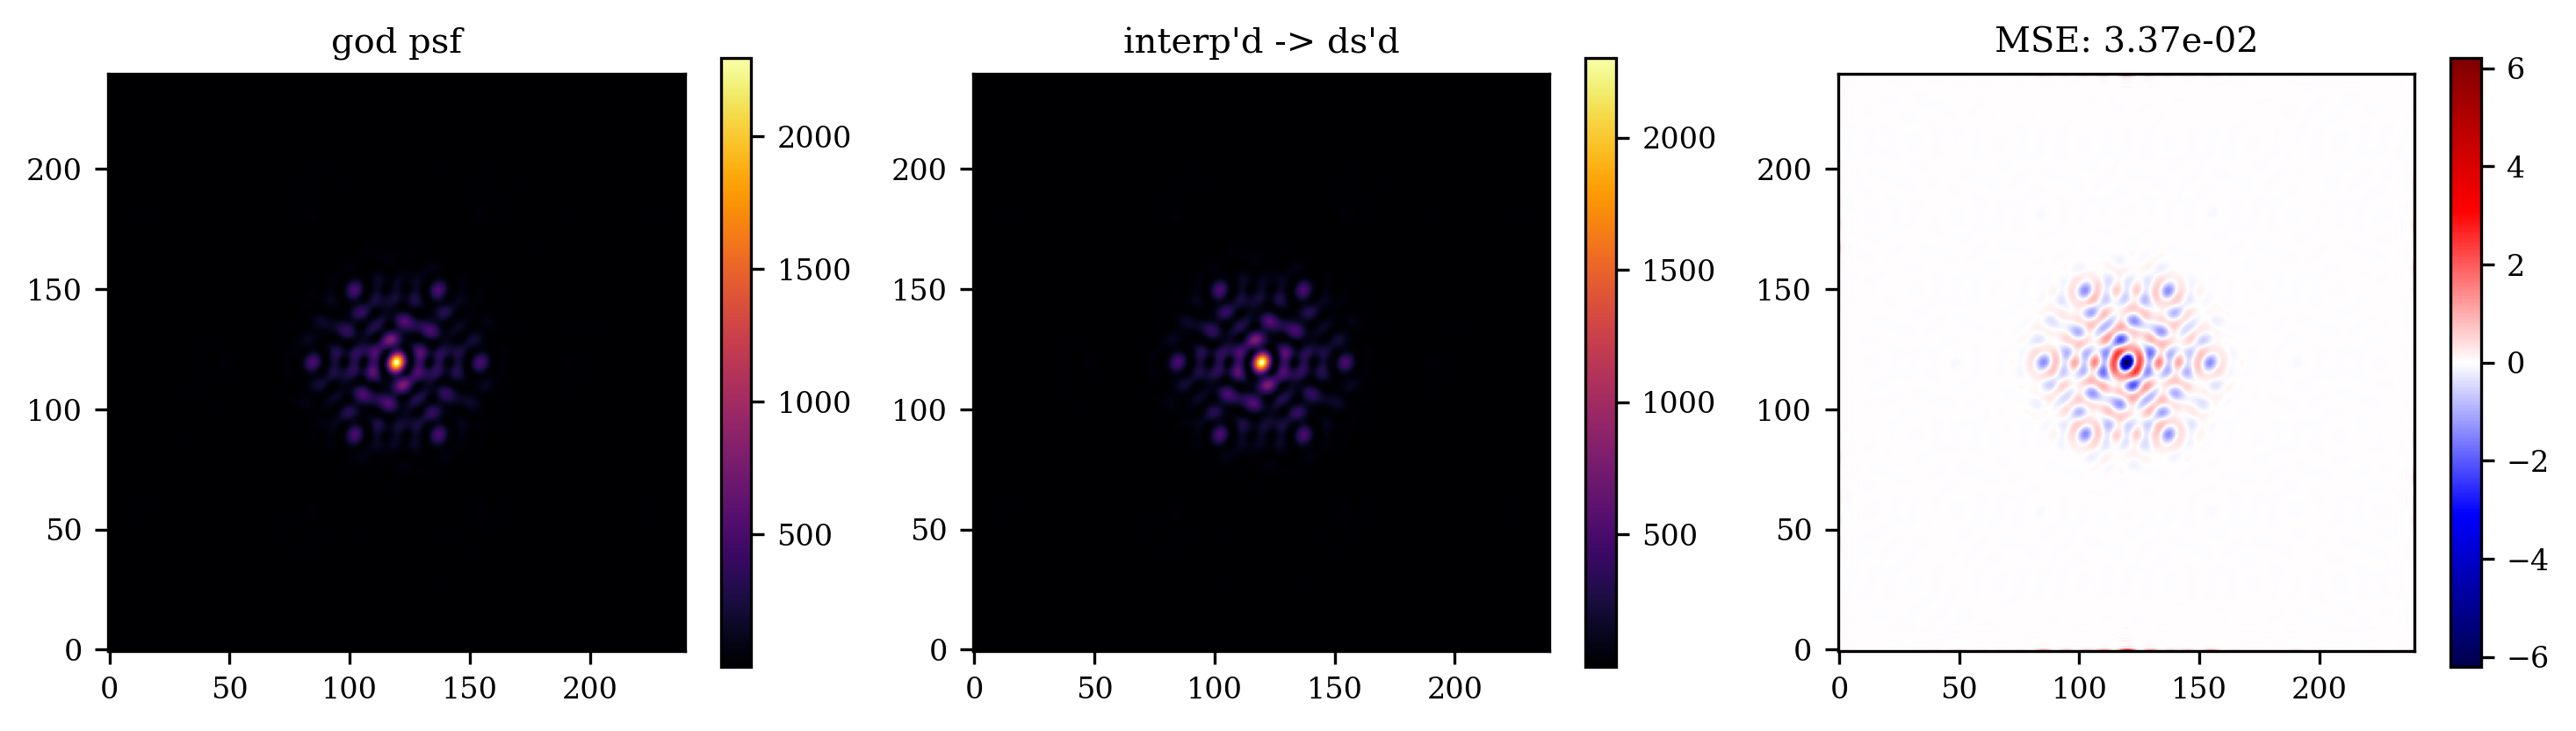

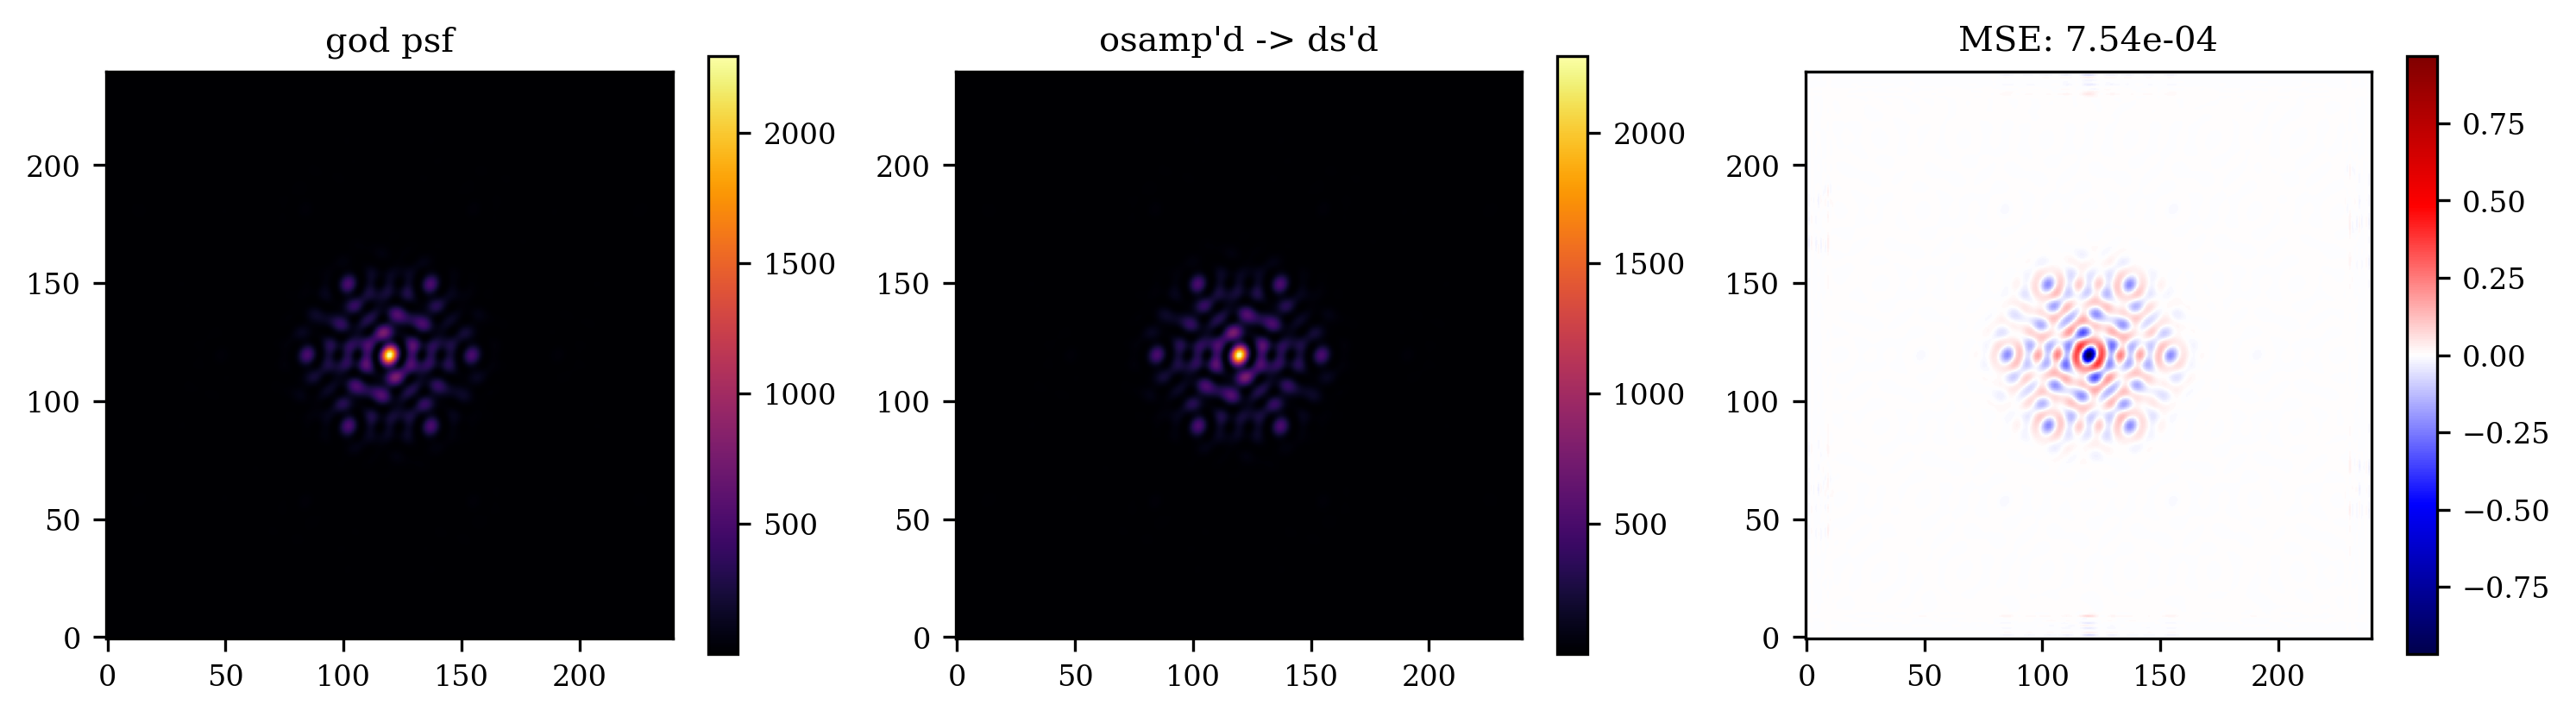

Filter: F430M, Oversampling: 3
(240, 240) (720, 720) (240, 240)


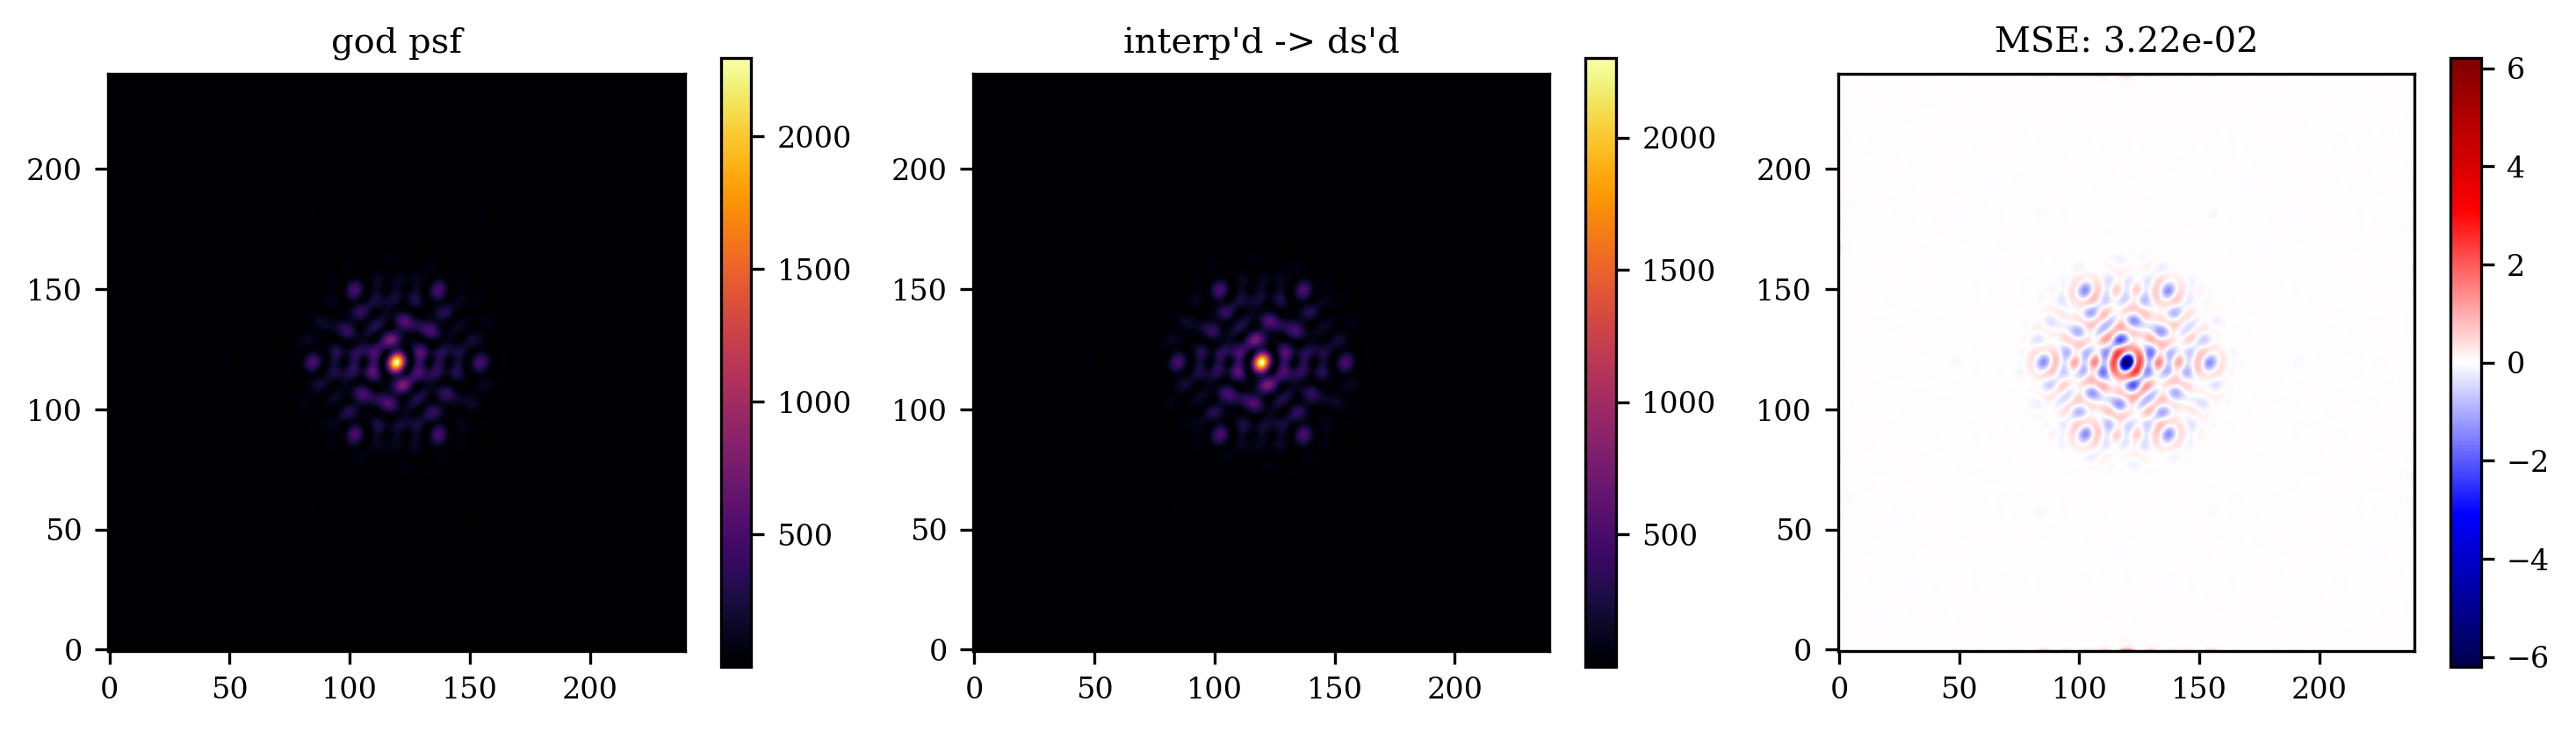

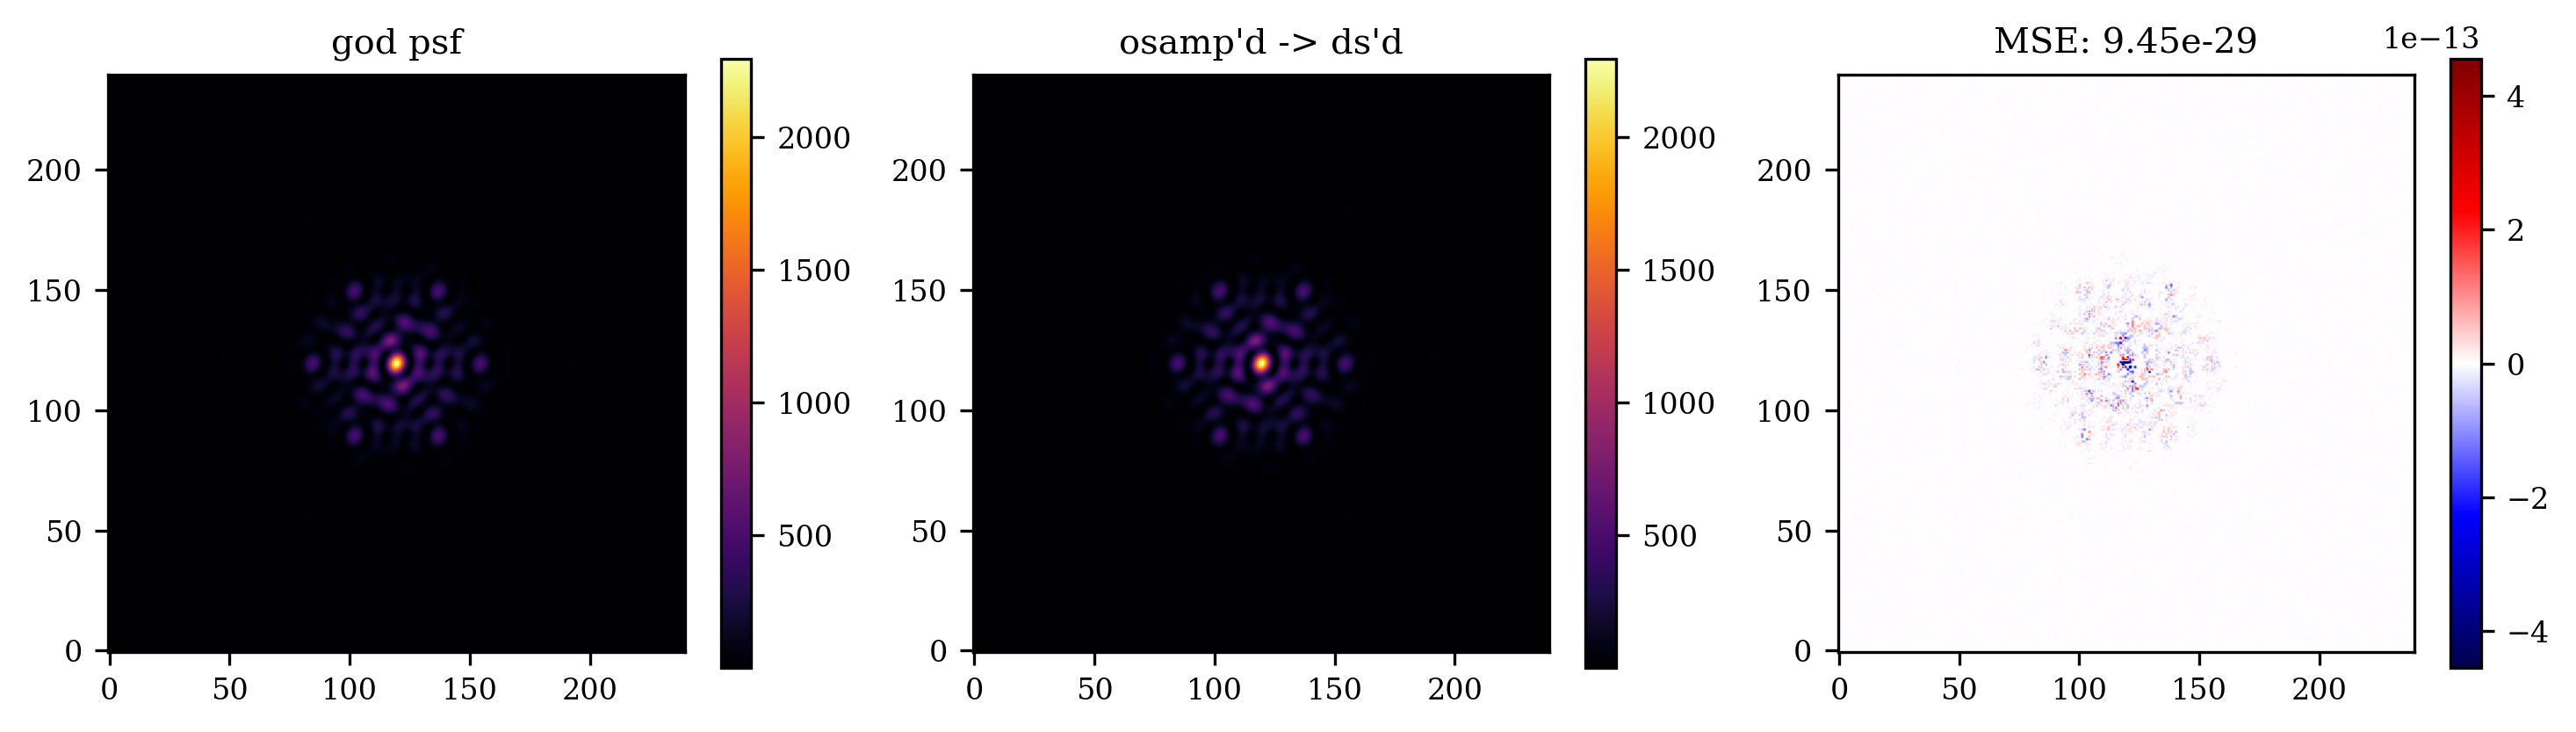

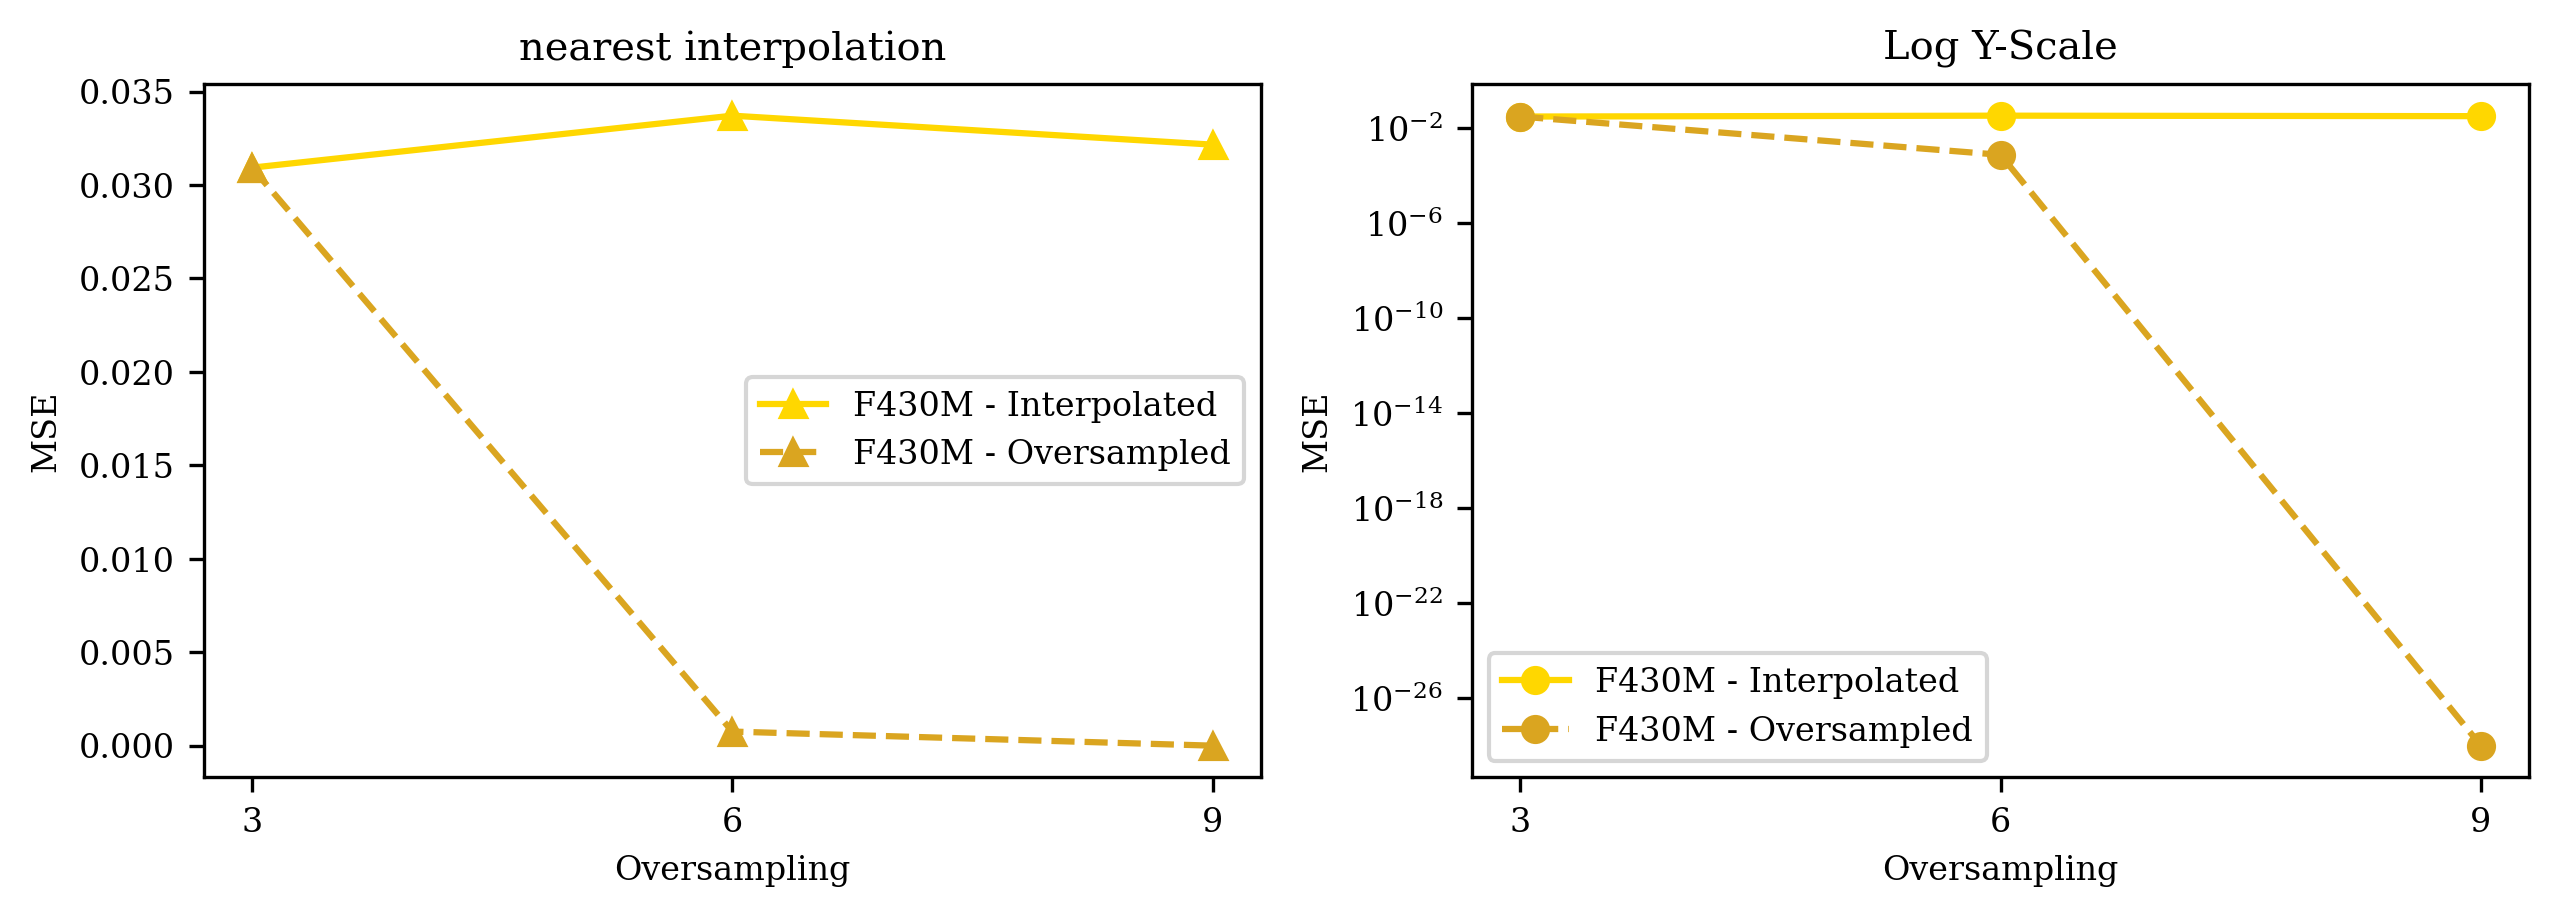

Filter: F430M, Oversampling: 1
(240, 240) (240, 240) (240, 240)


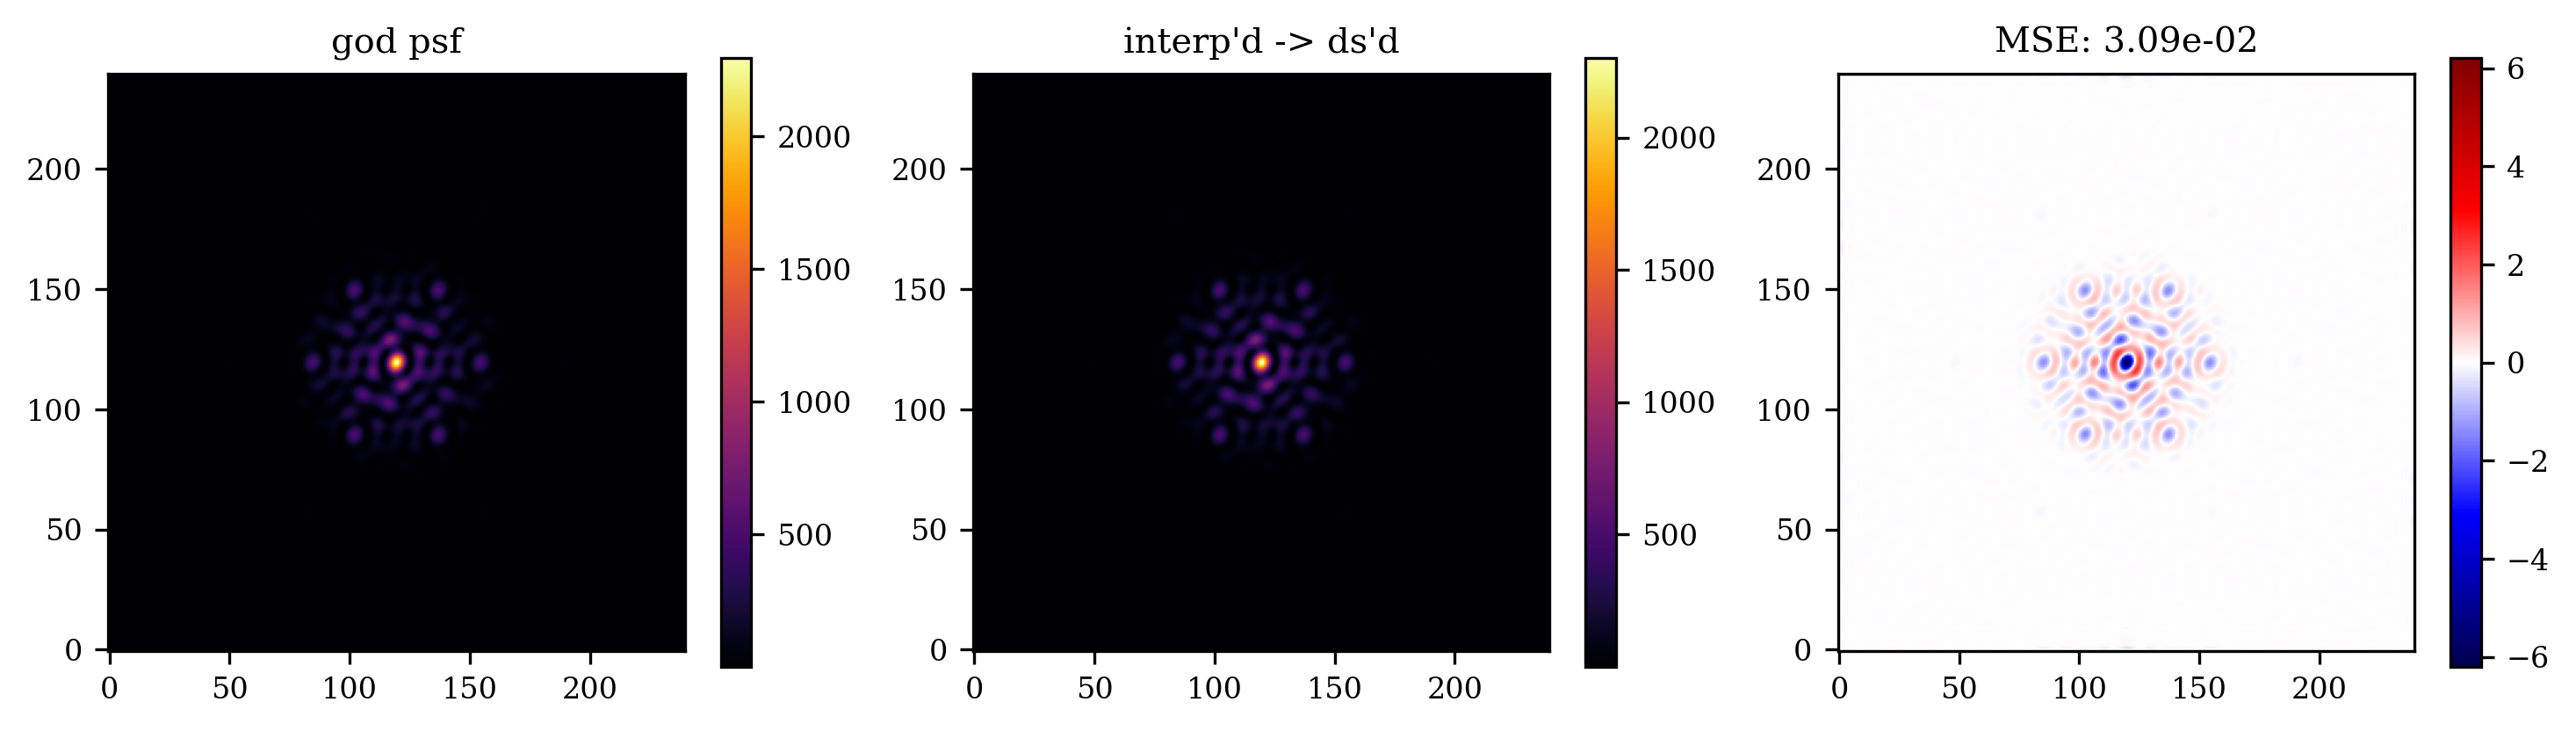

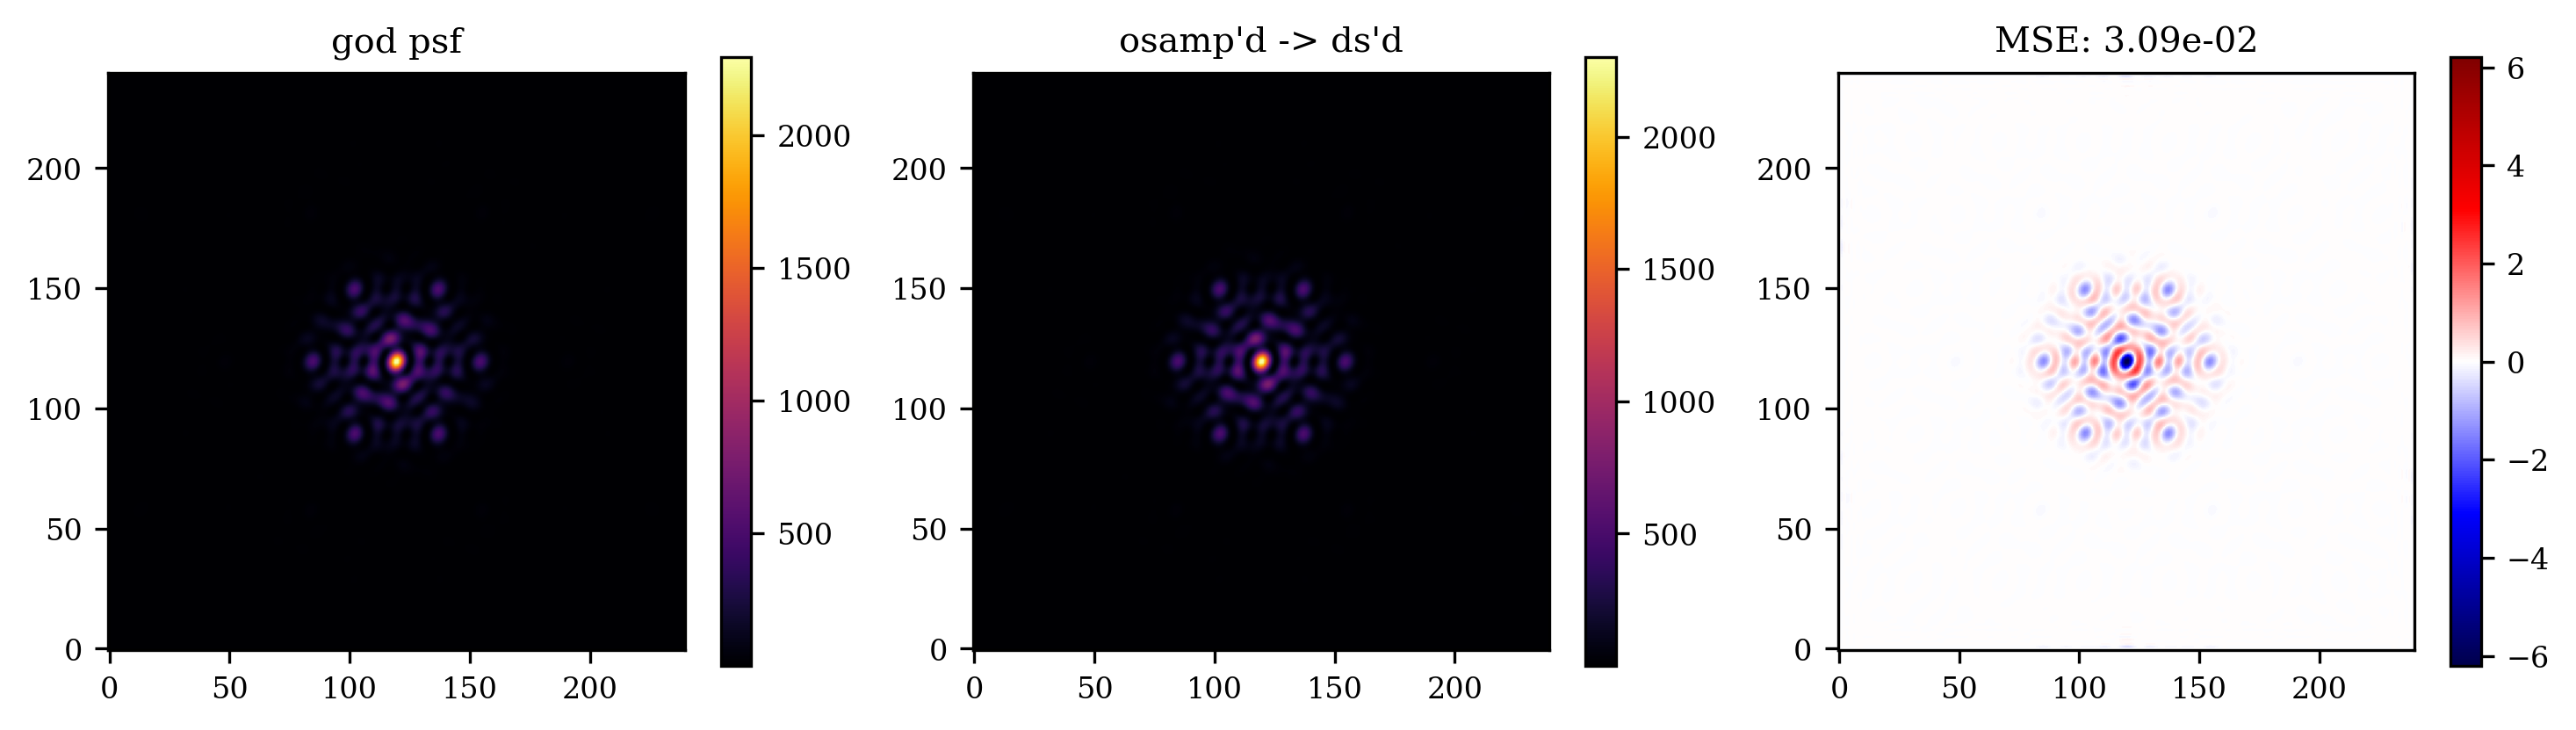

Filter: F430M, Oversampling: 2
(240, 240) (480, 480) (240, 240)


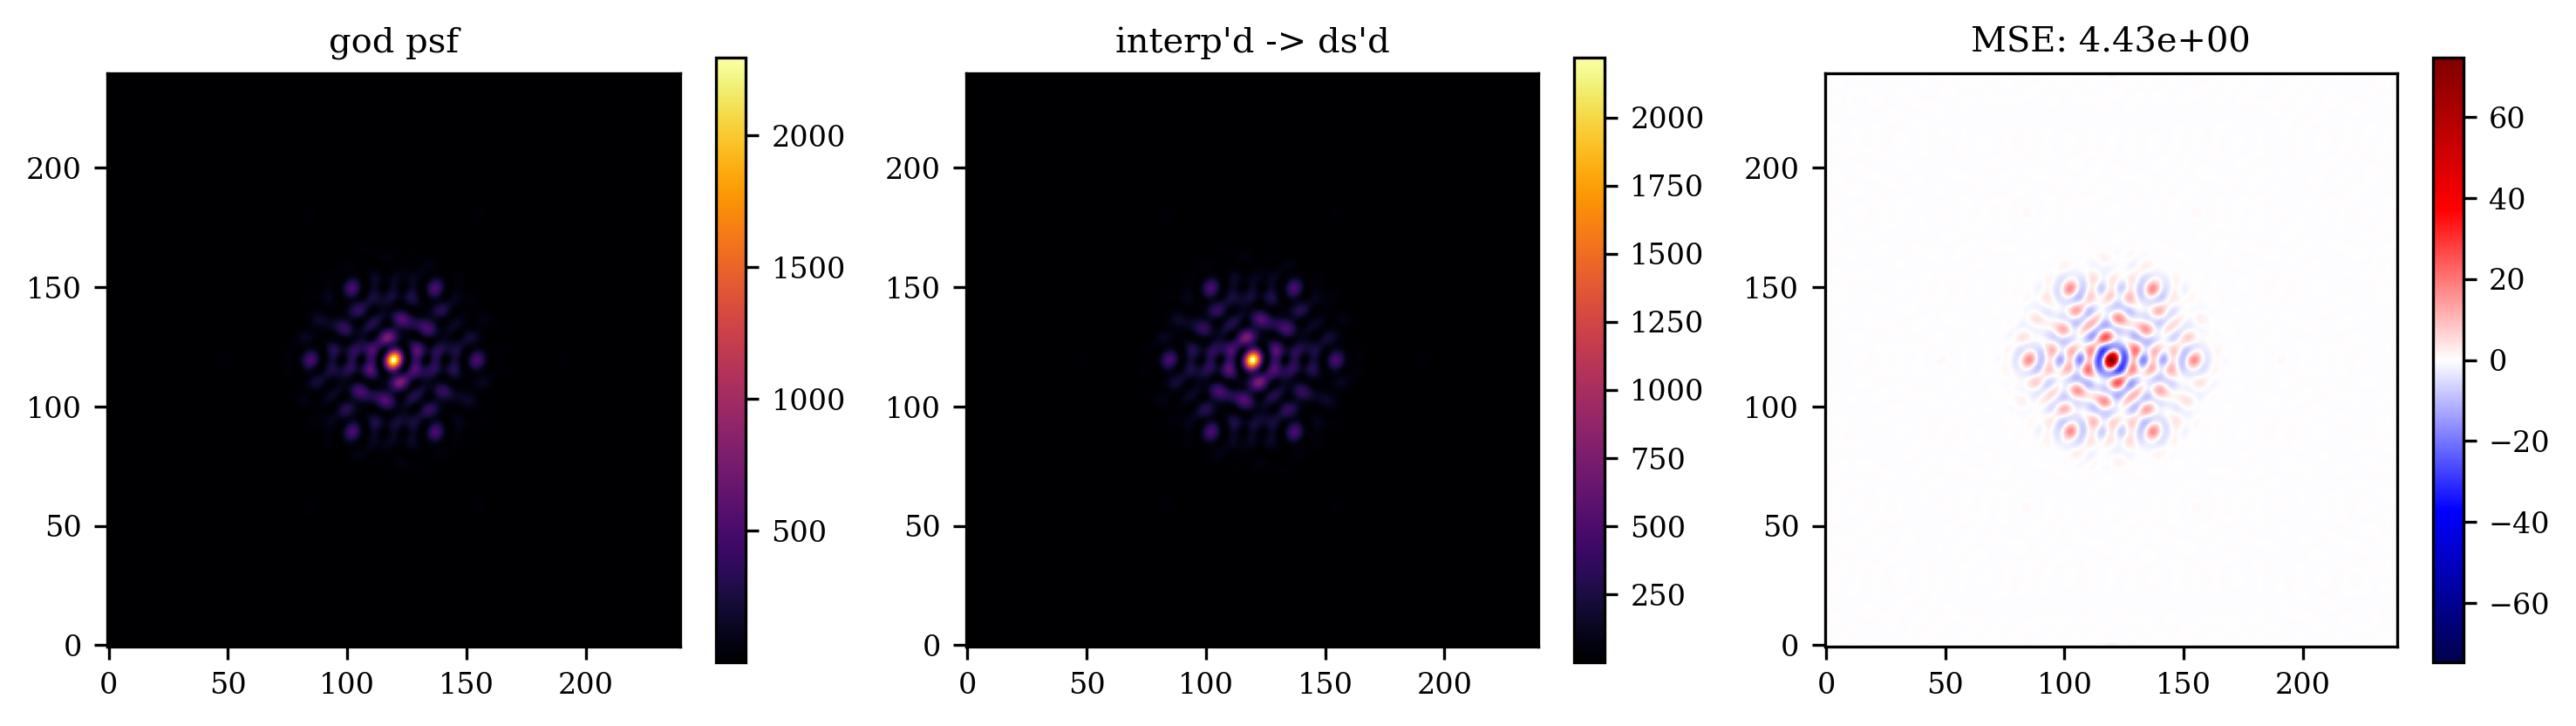

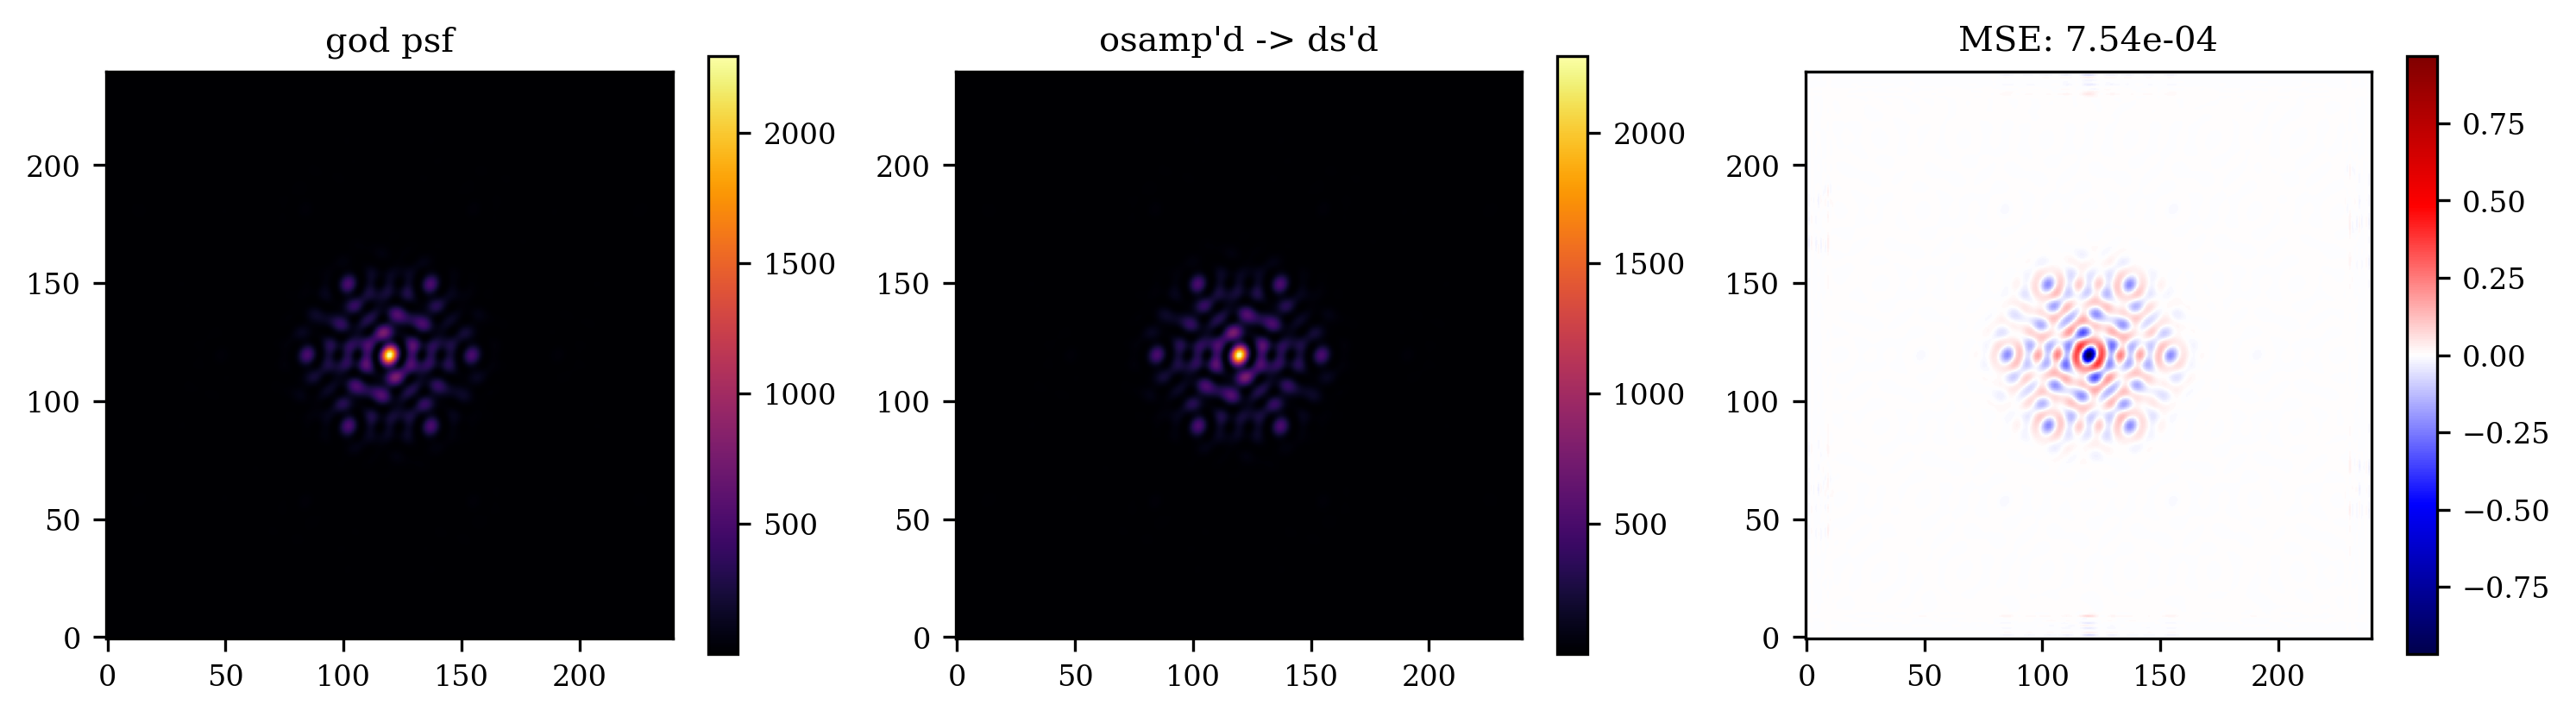

Filter: F430M, Oversampling: 3
(240, 240) (720, 720) (240, 240)


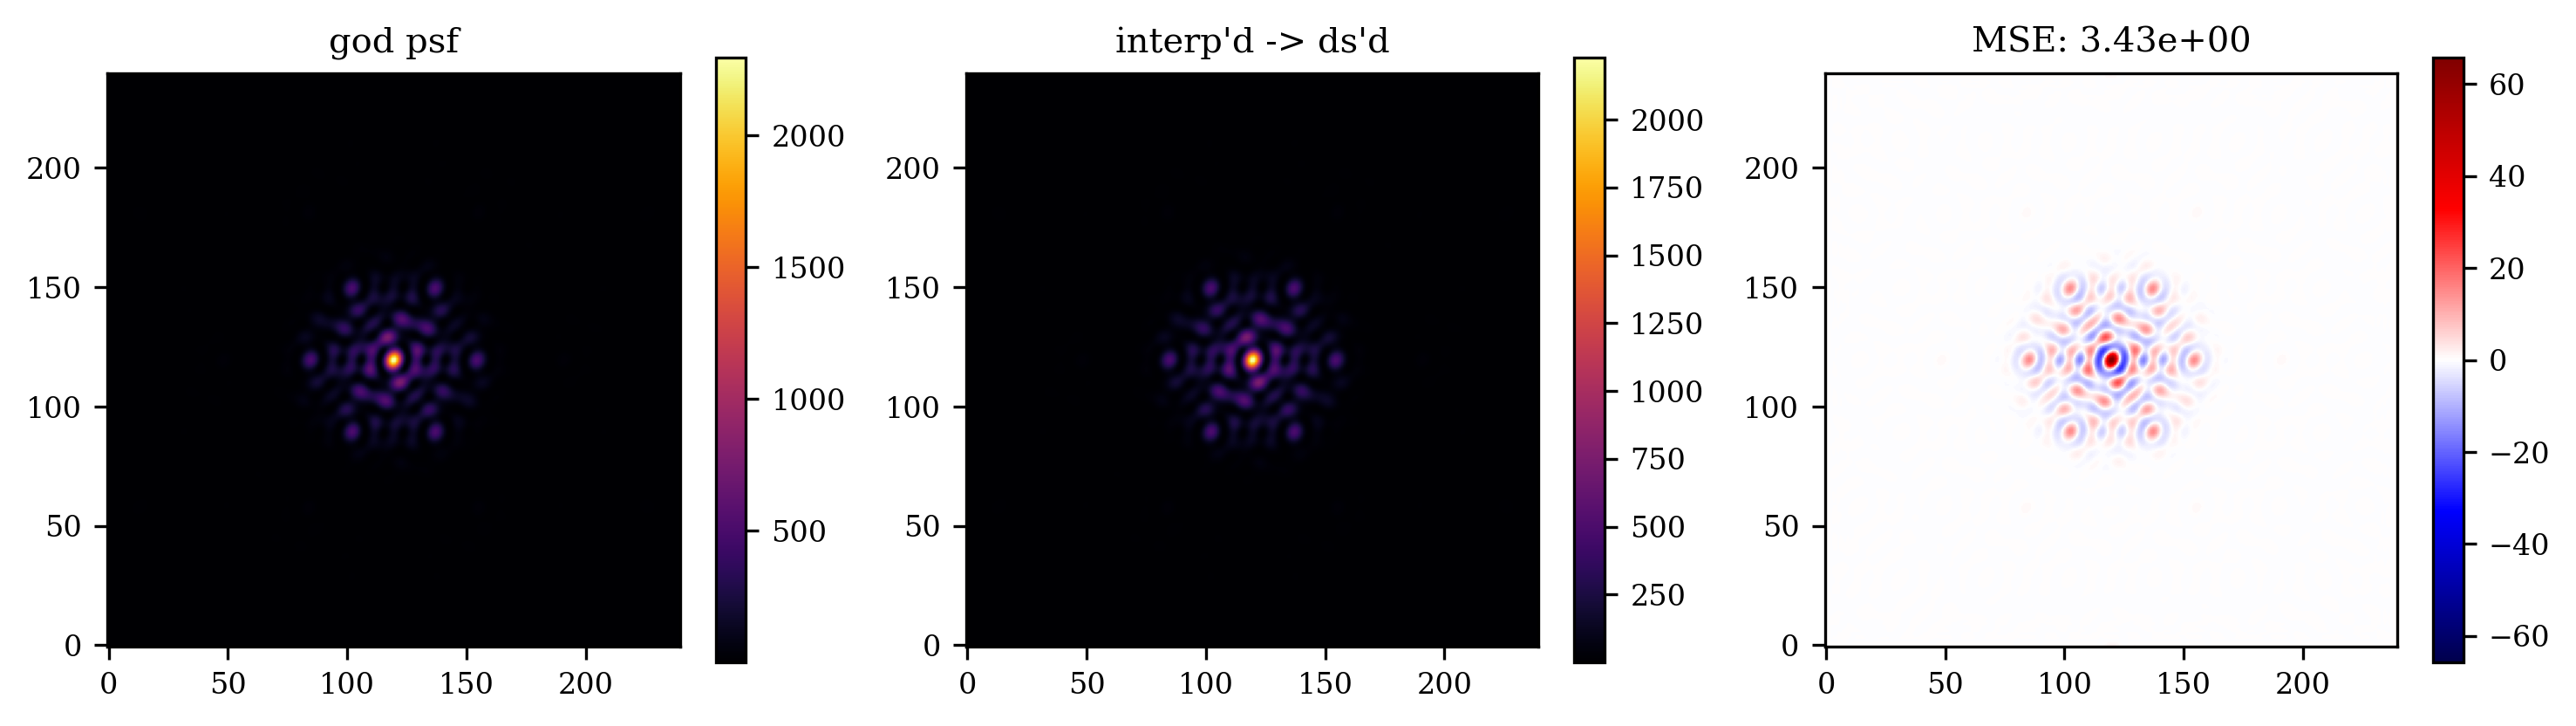

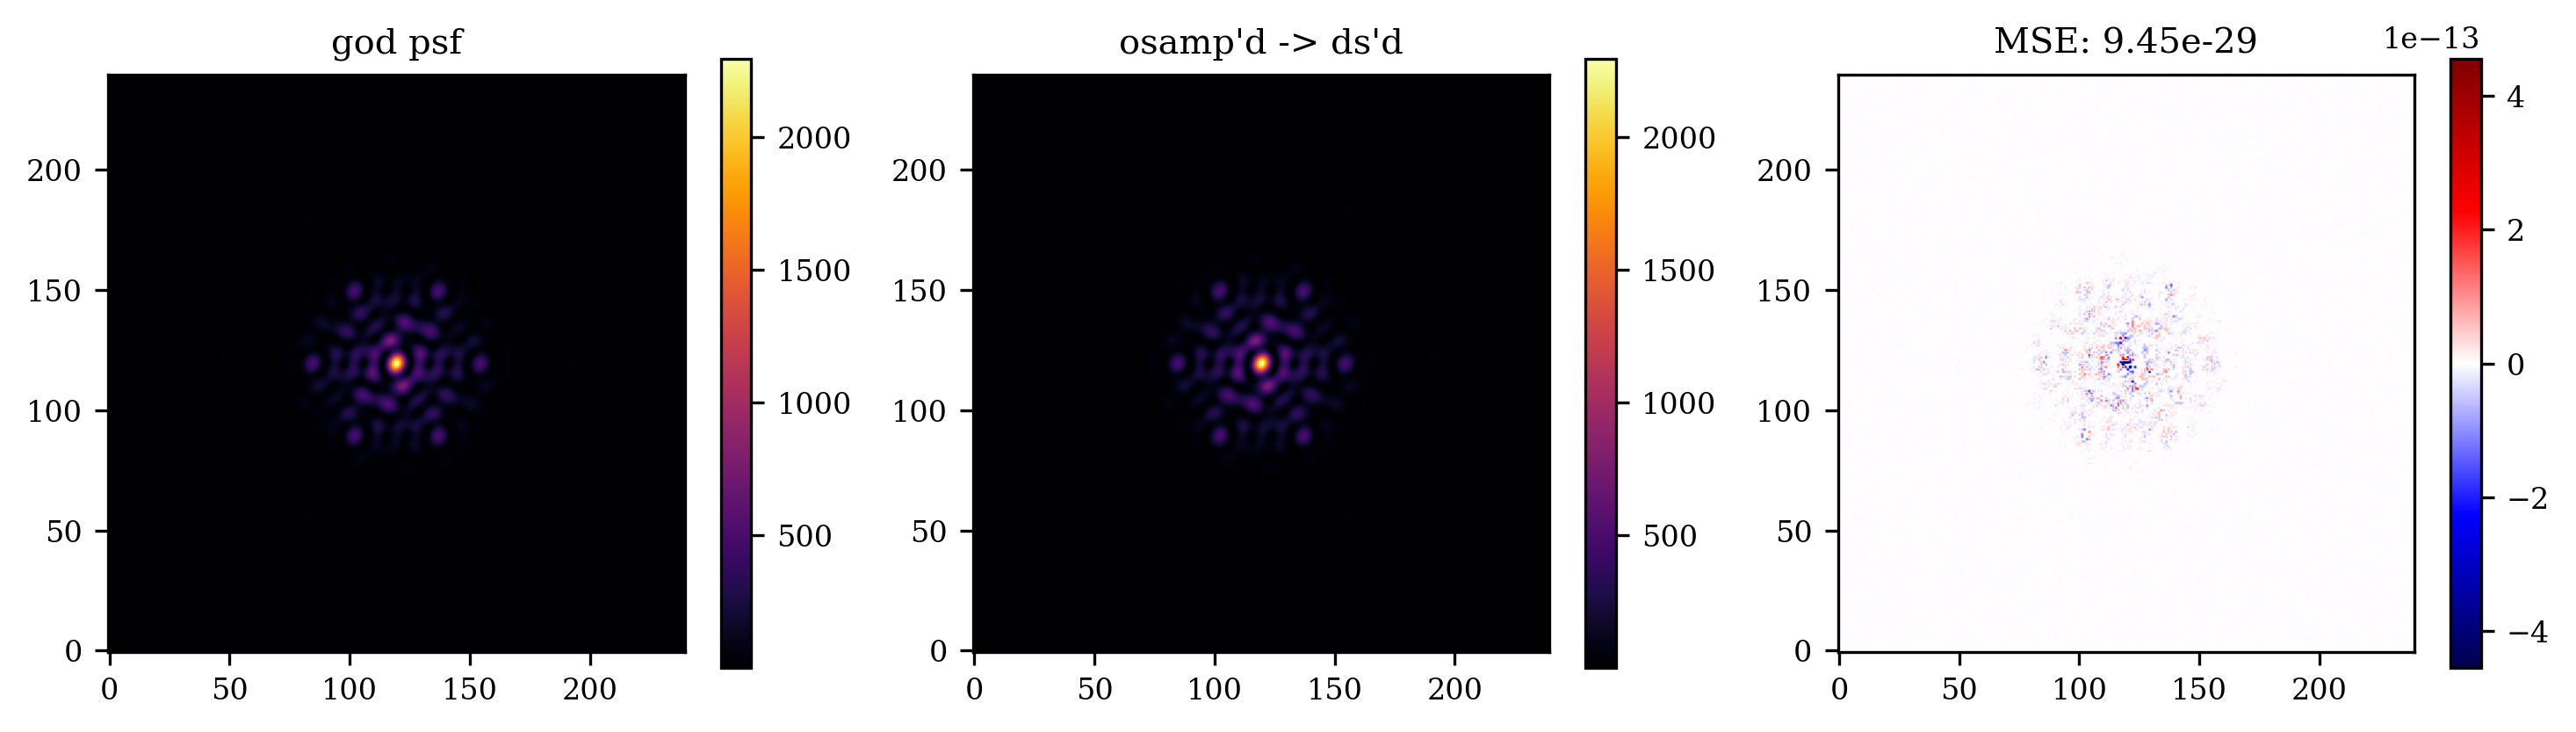

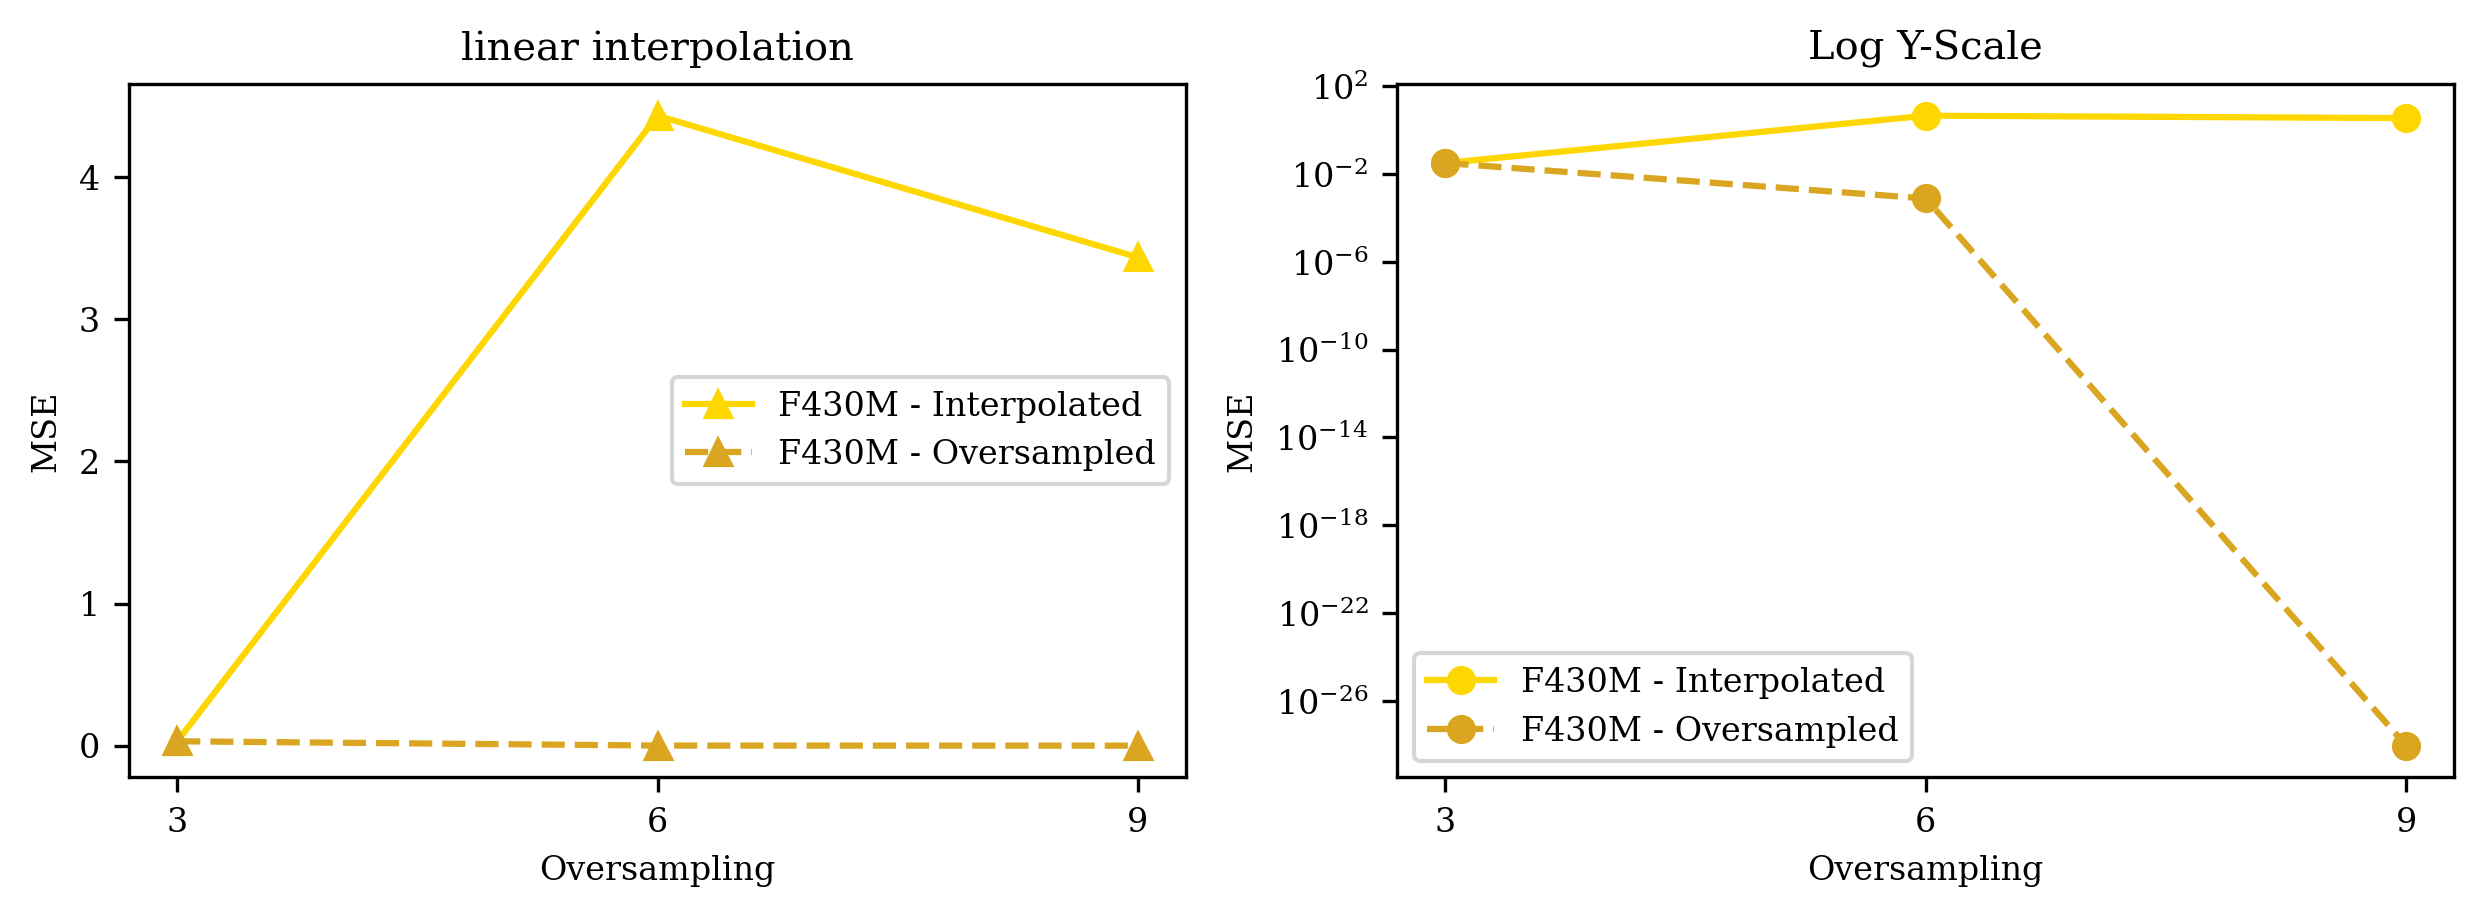

Filter: F430M, Oversampling: 1
(240, 240) (240, 240) (240, 240)


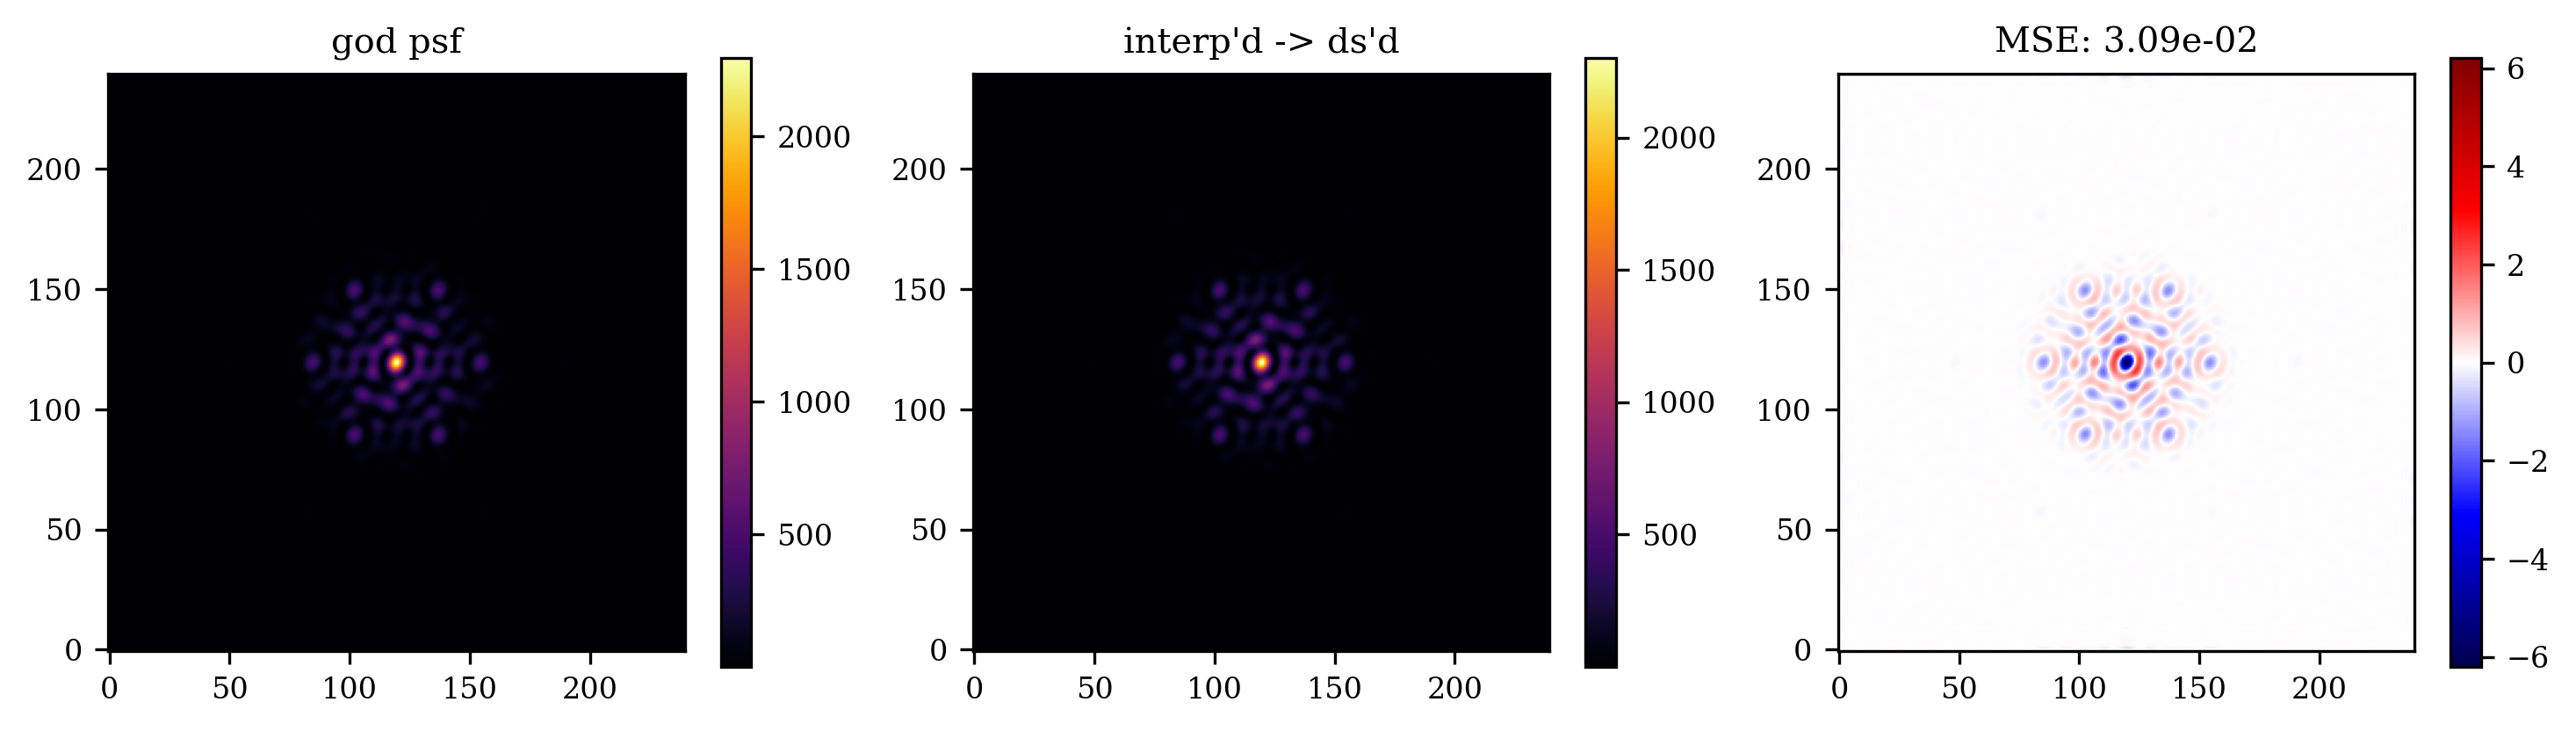

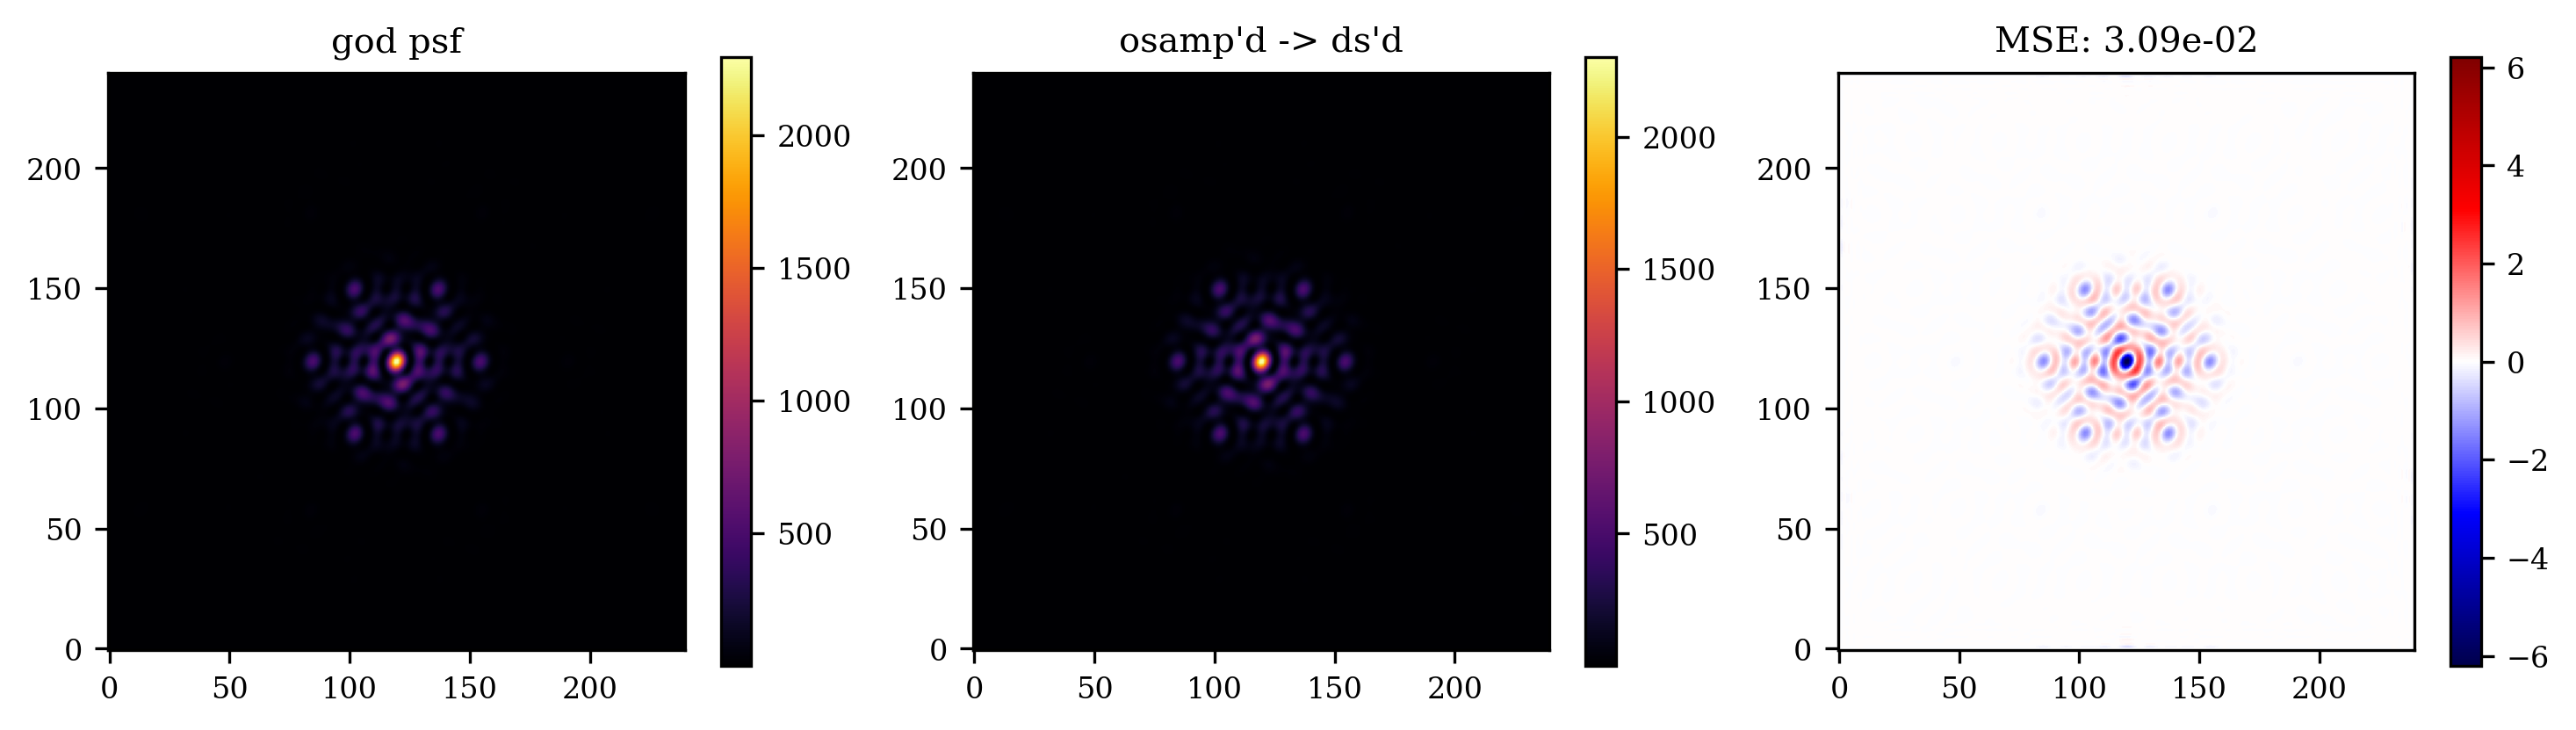

Filter: F430M, Oversampling: 2
(240, 240) (480, 480) (240, 240)


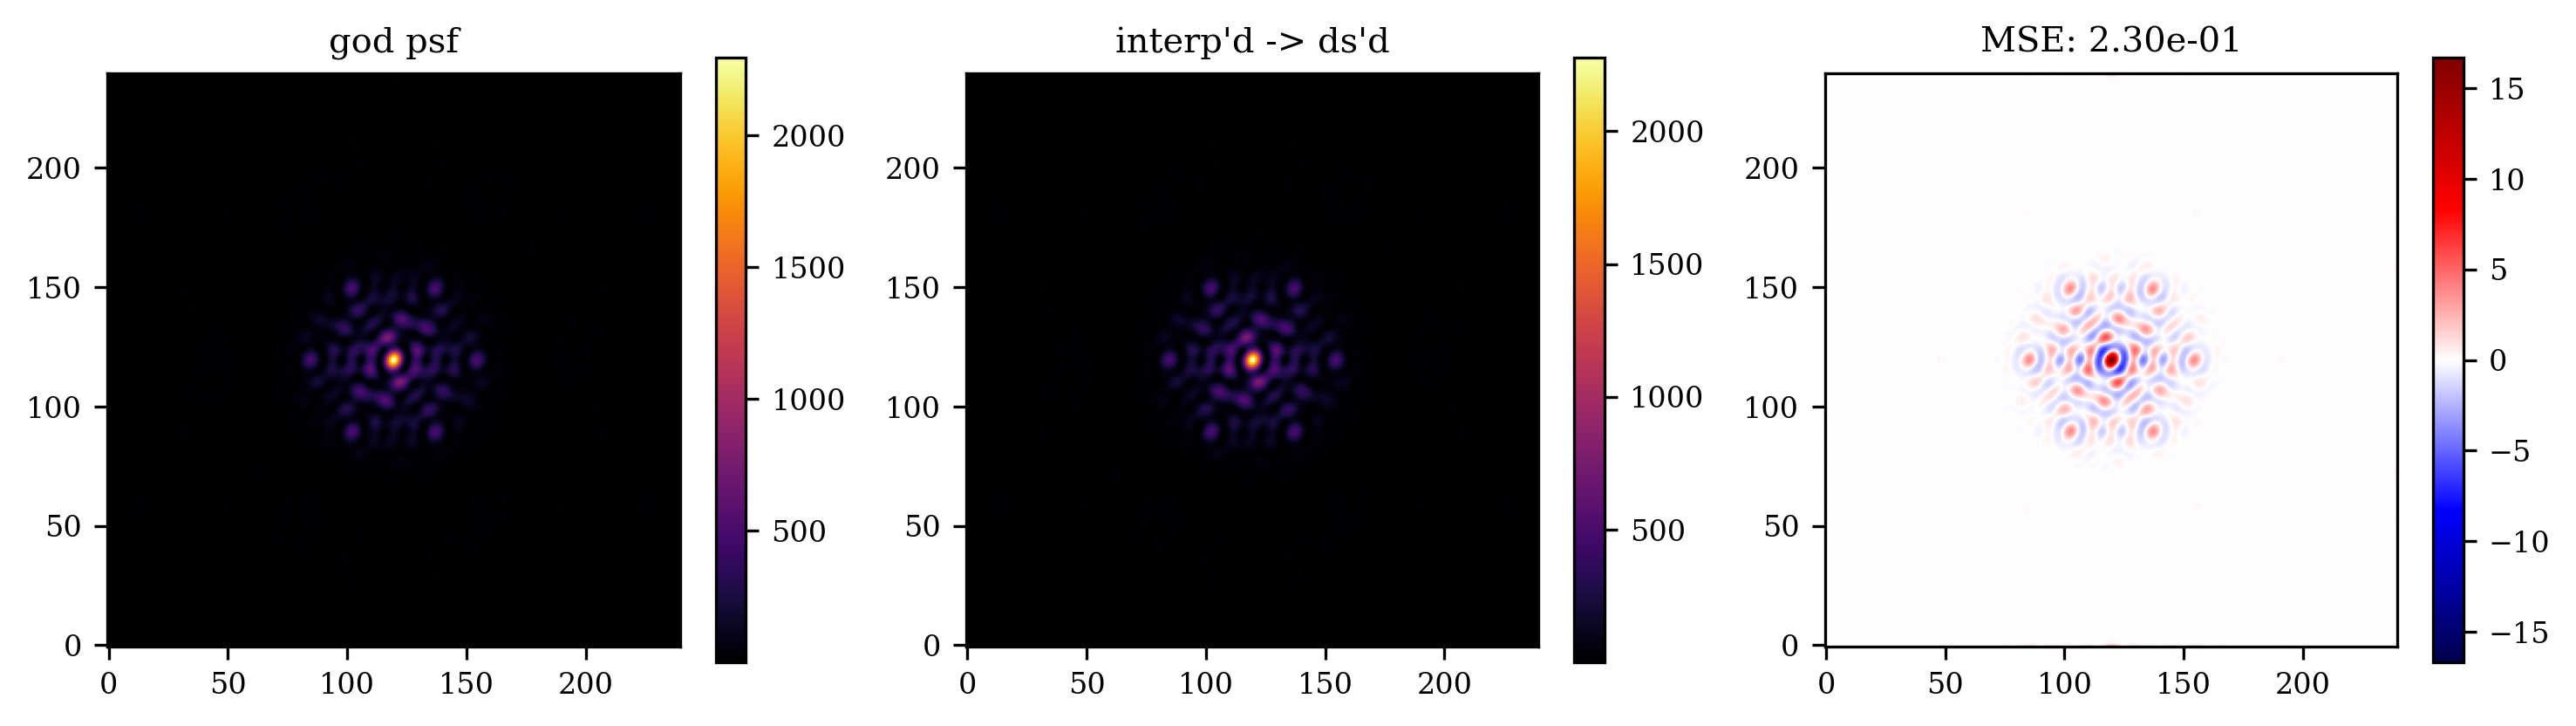

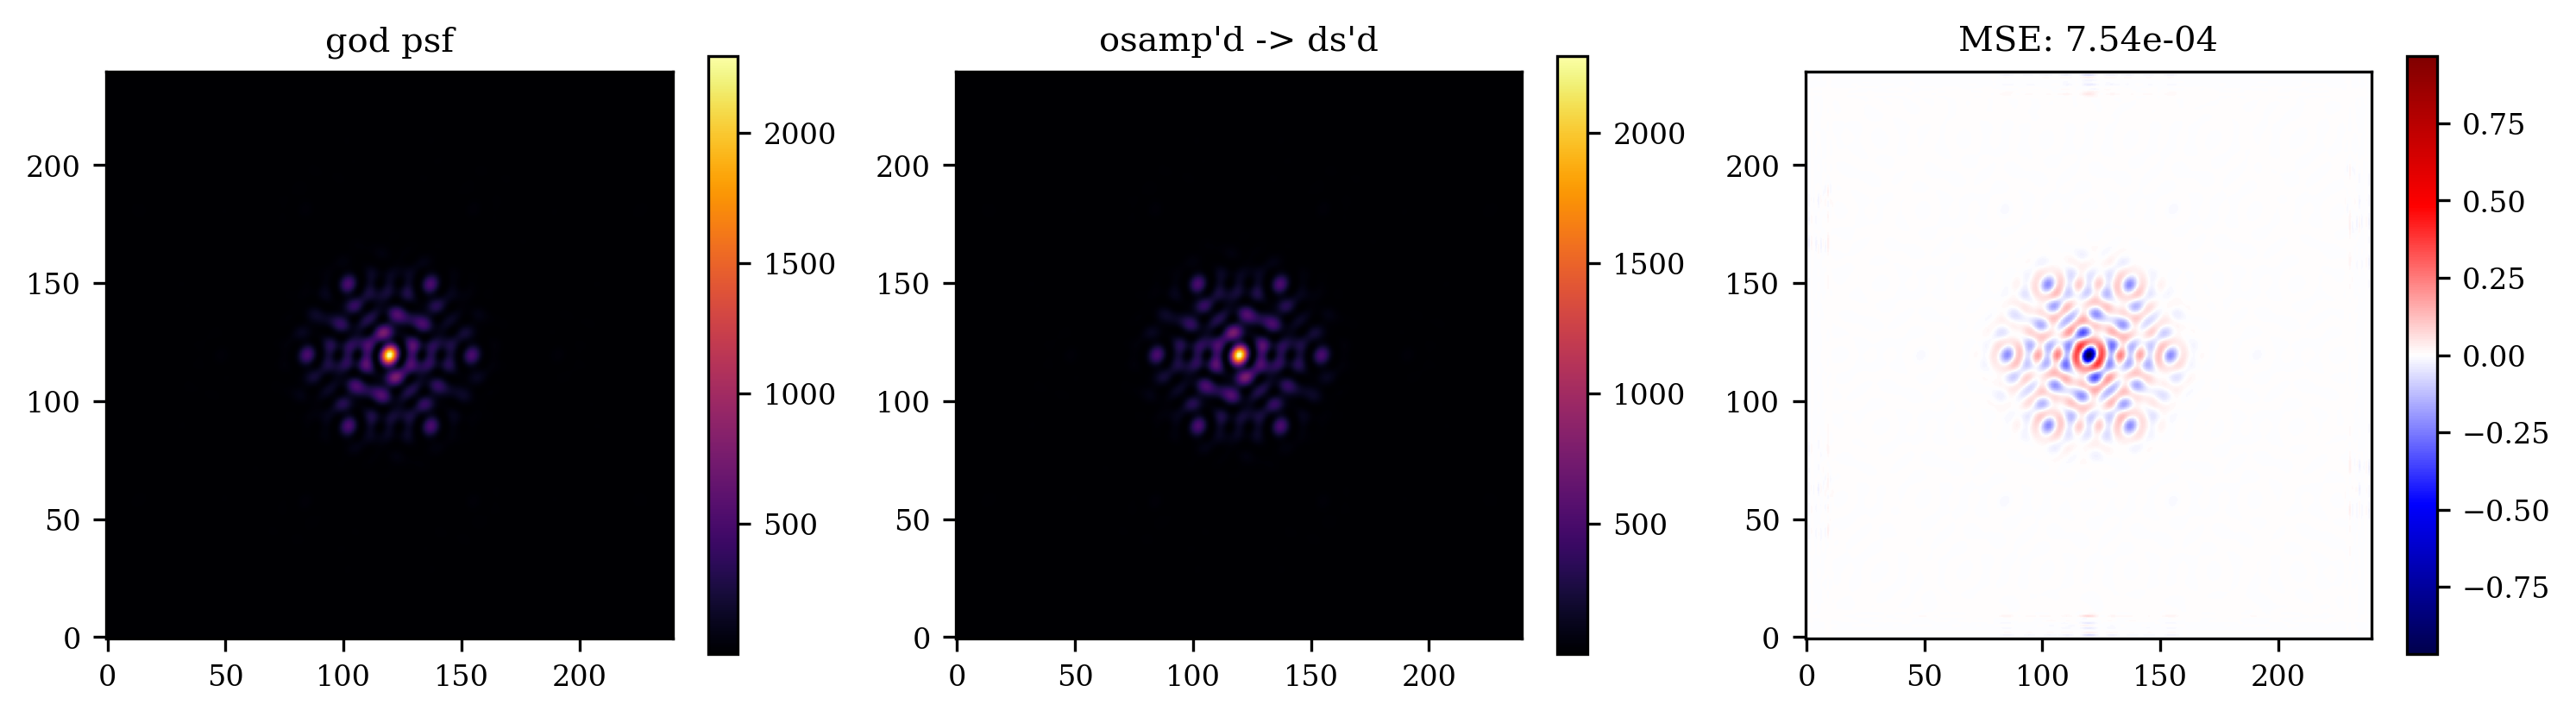

Filter: F430M, Oversampling: 3
(240, 240) (720, 720) (240, 240)


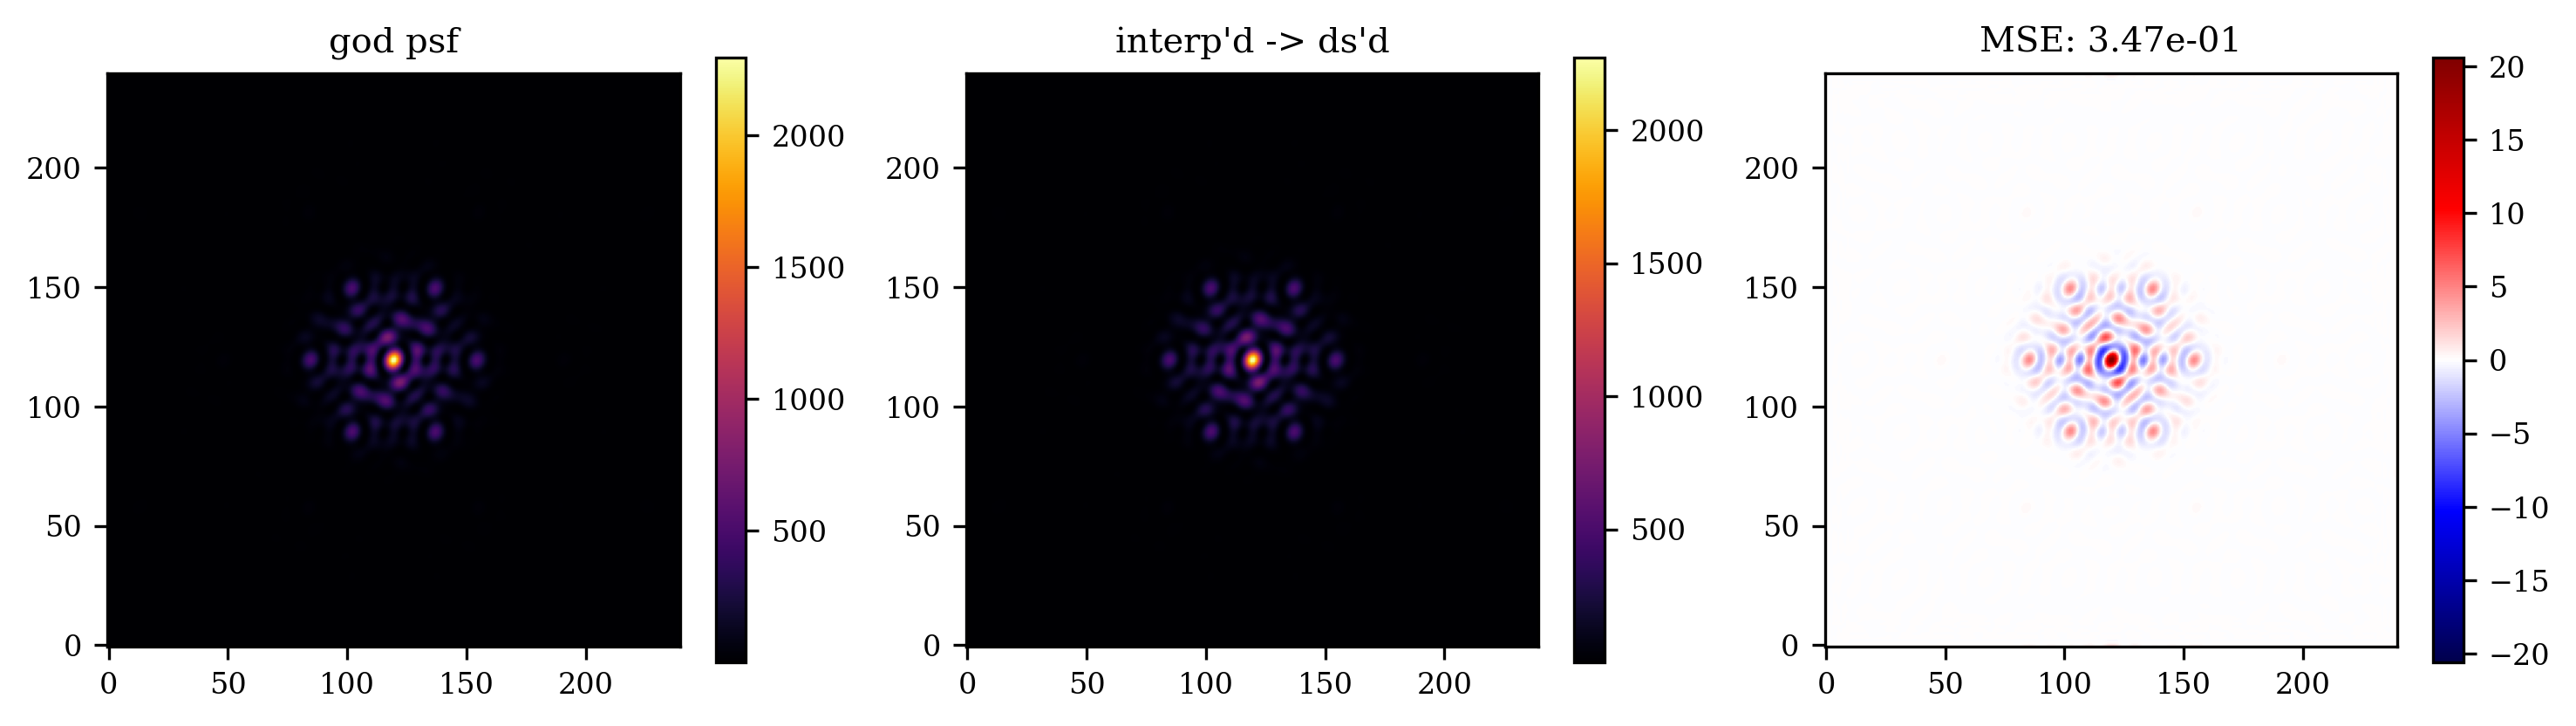

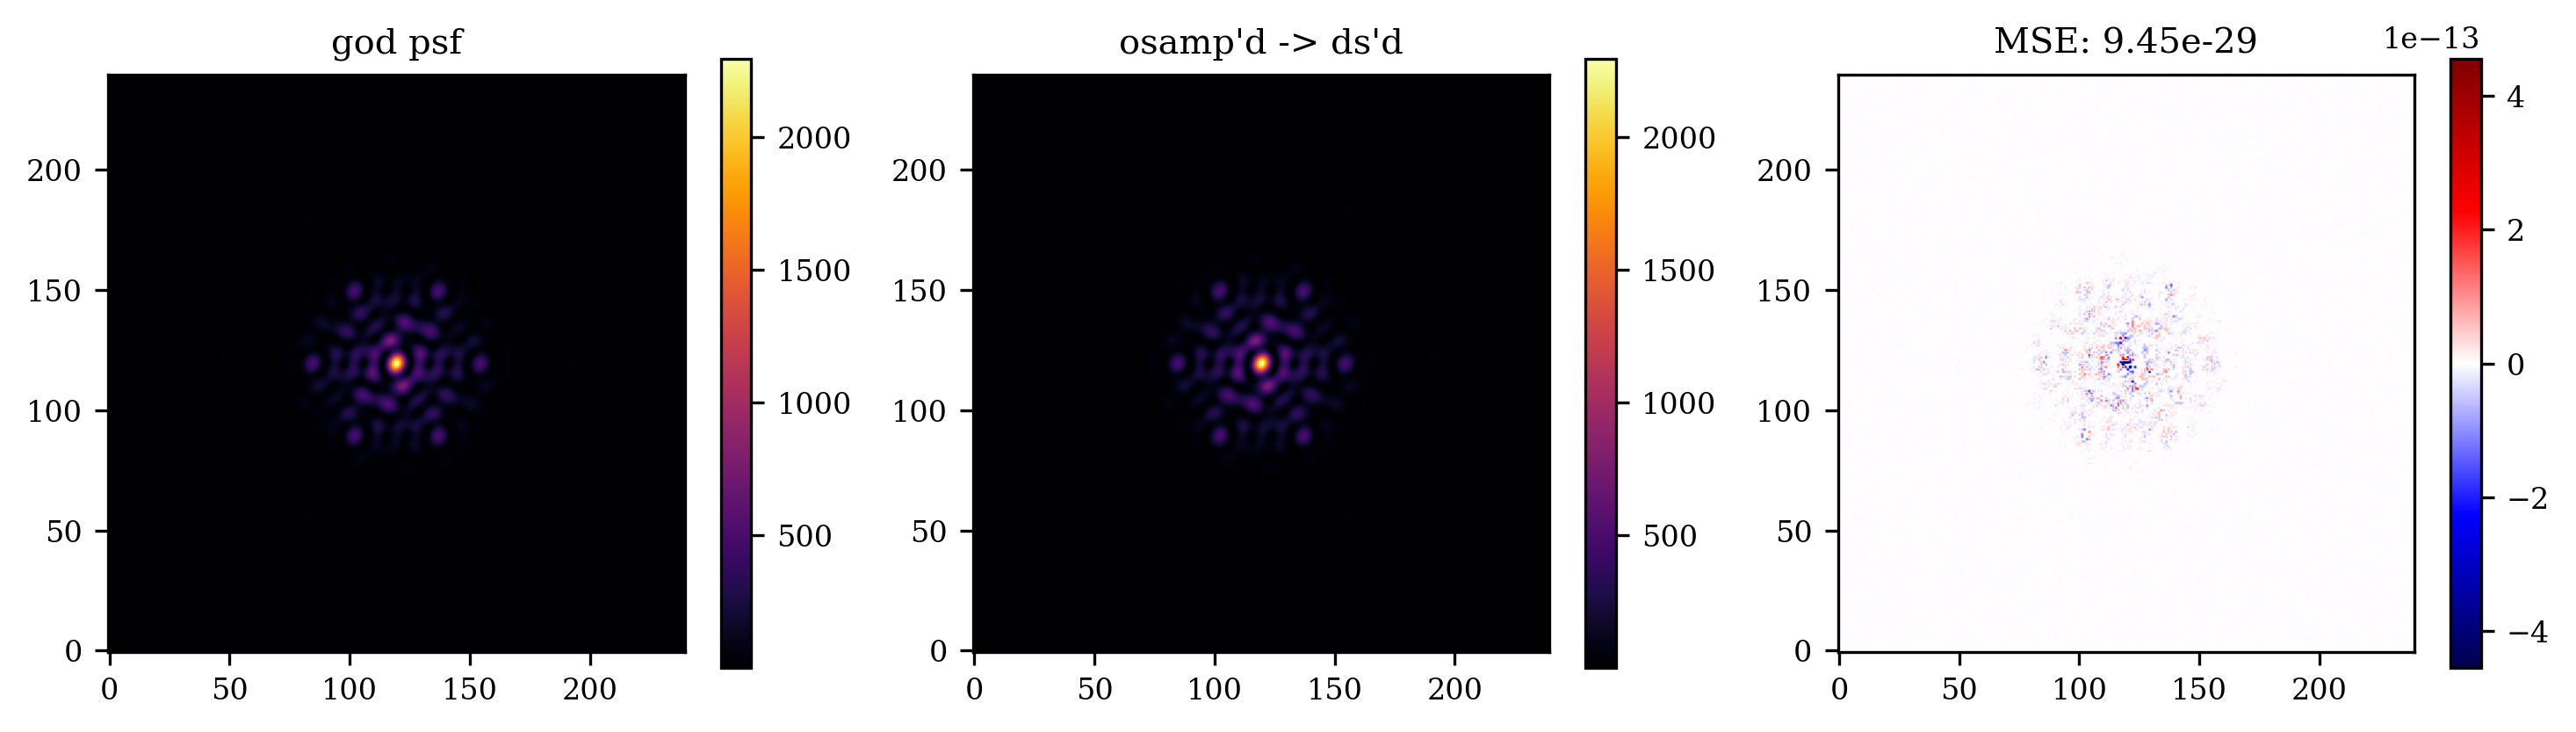

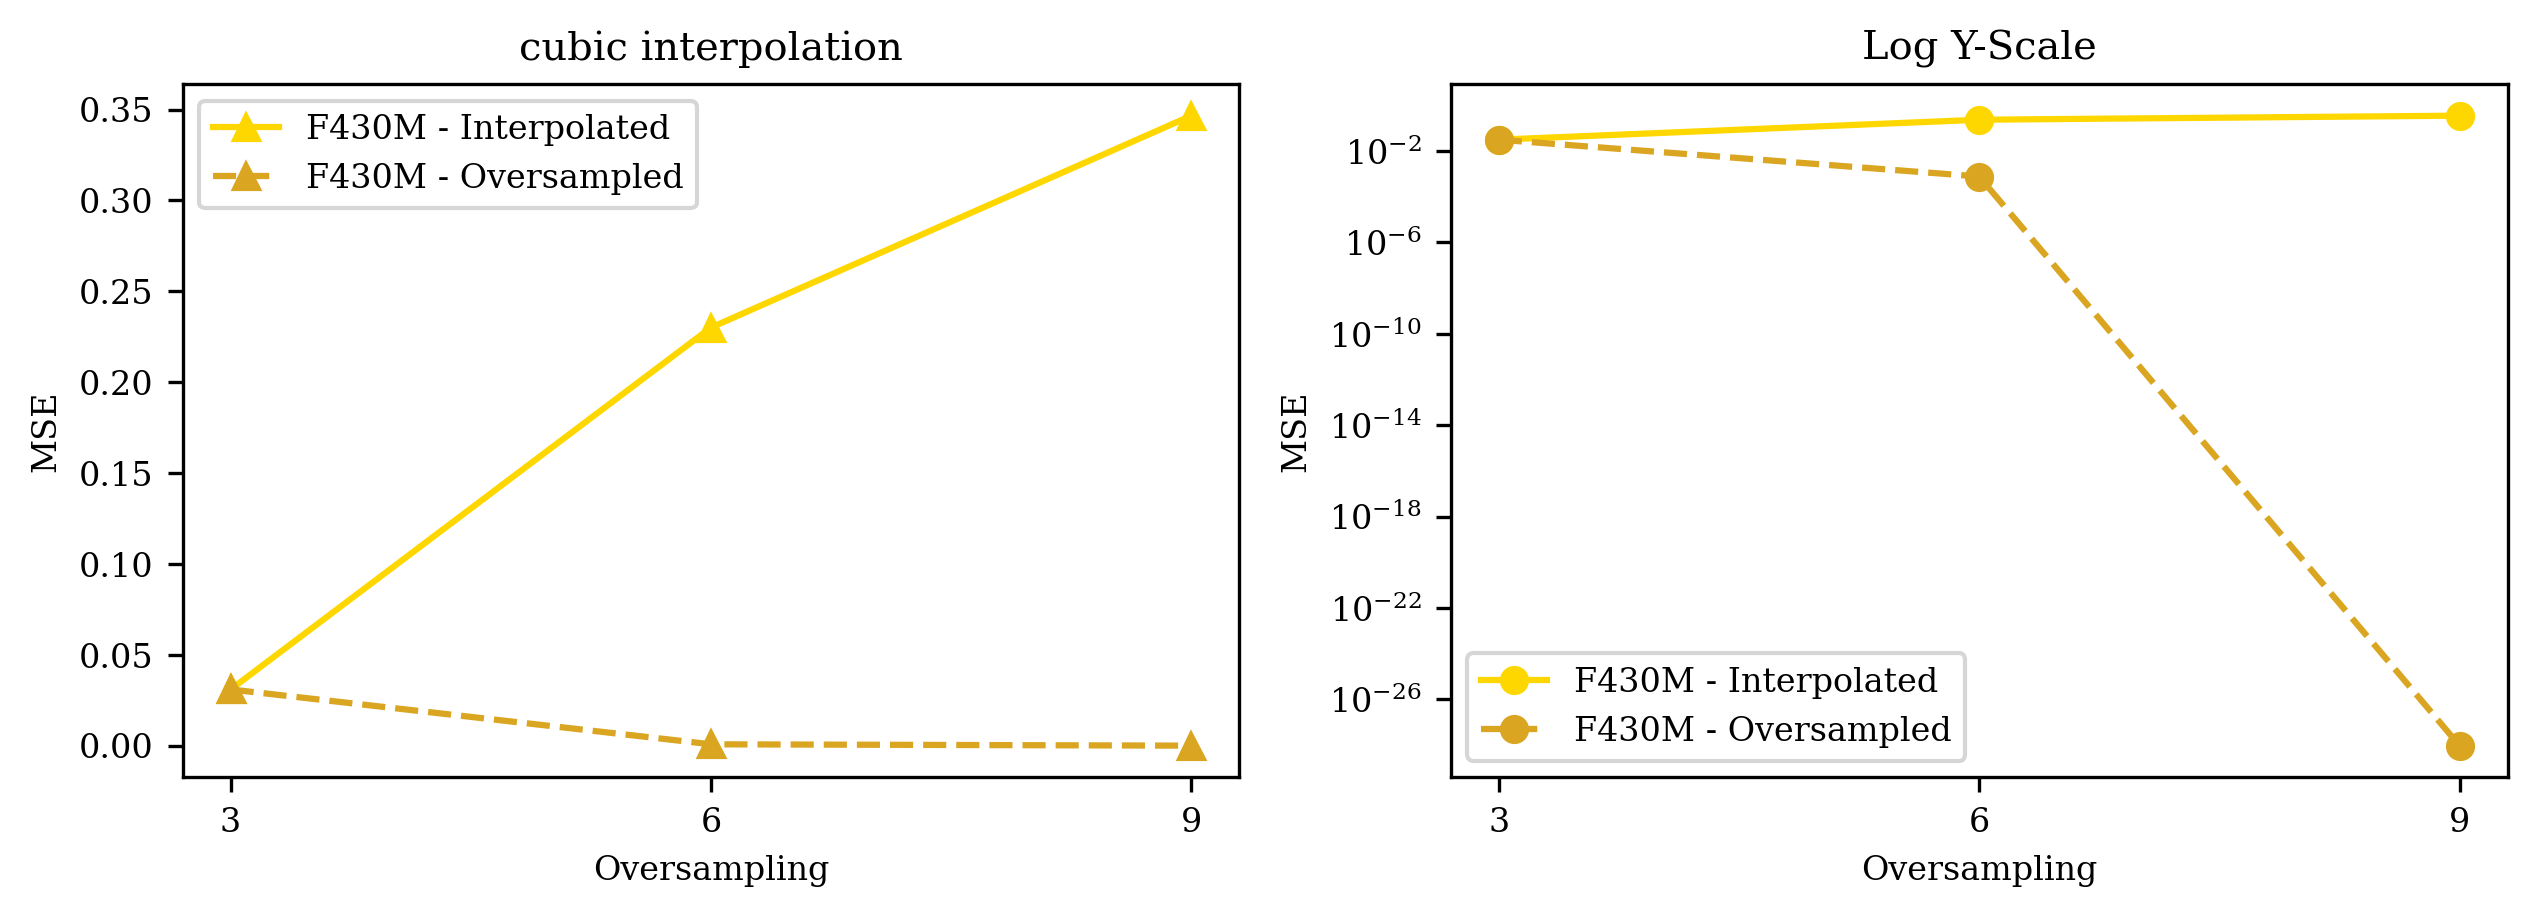

Filter: F430M, Oversampling: 1
(240, 240) (240, 240) (240, 240)


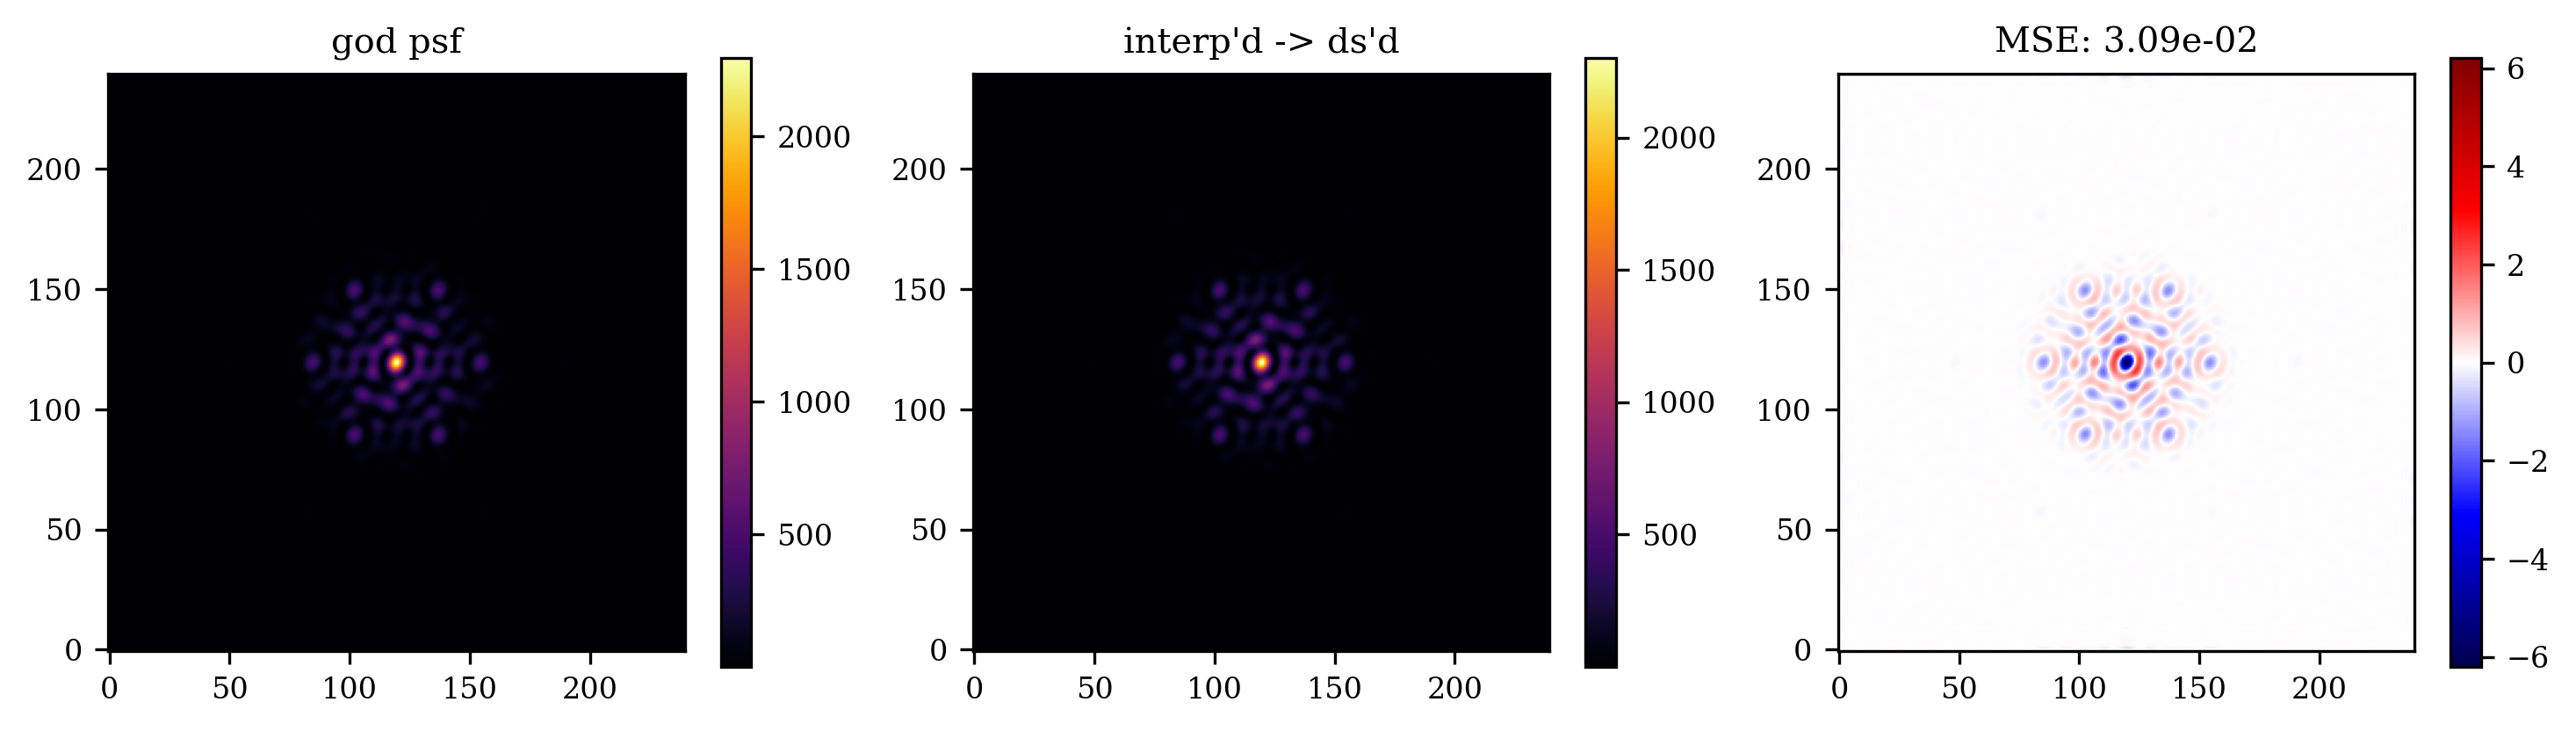

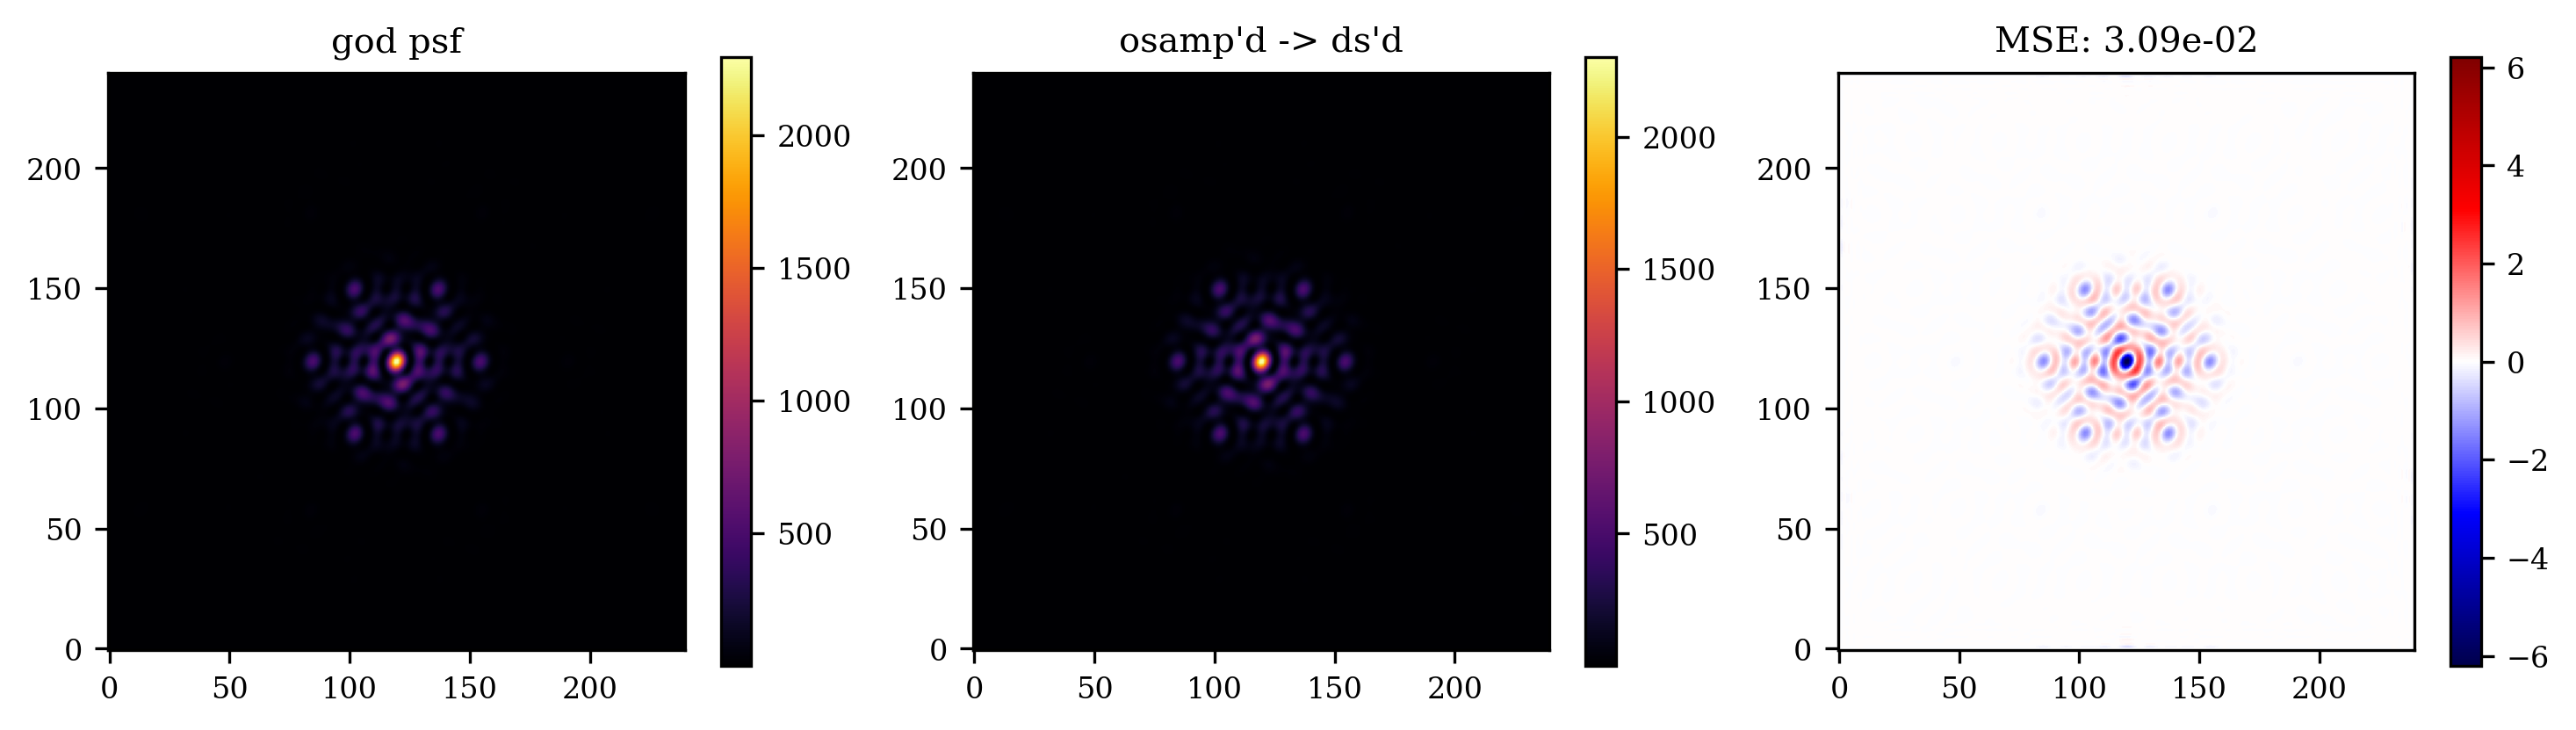

Filter: F430M, Oversampling: 2
(240, 240) (480, 480) (240, 240)


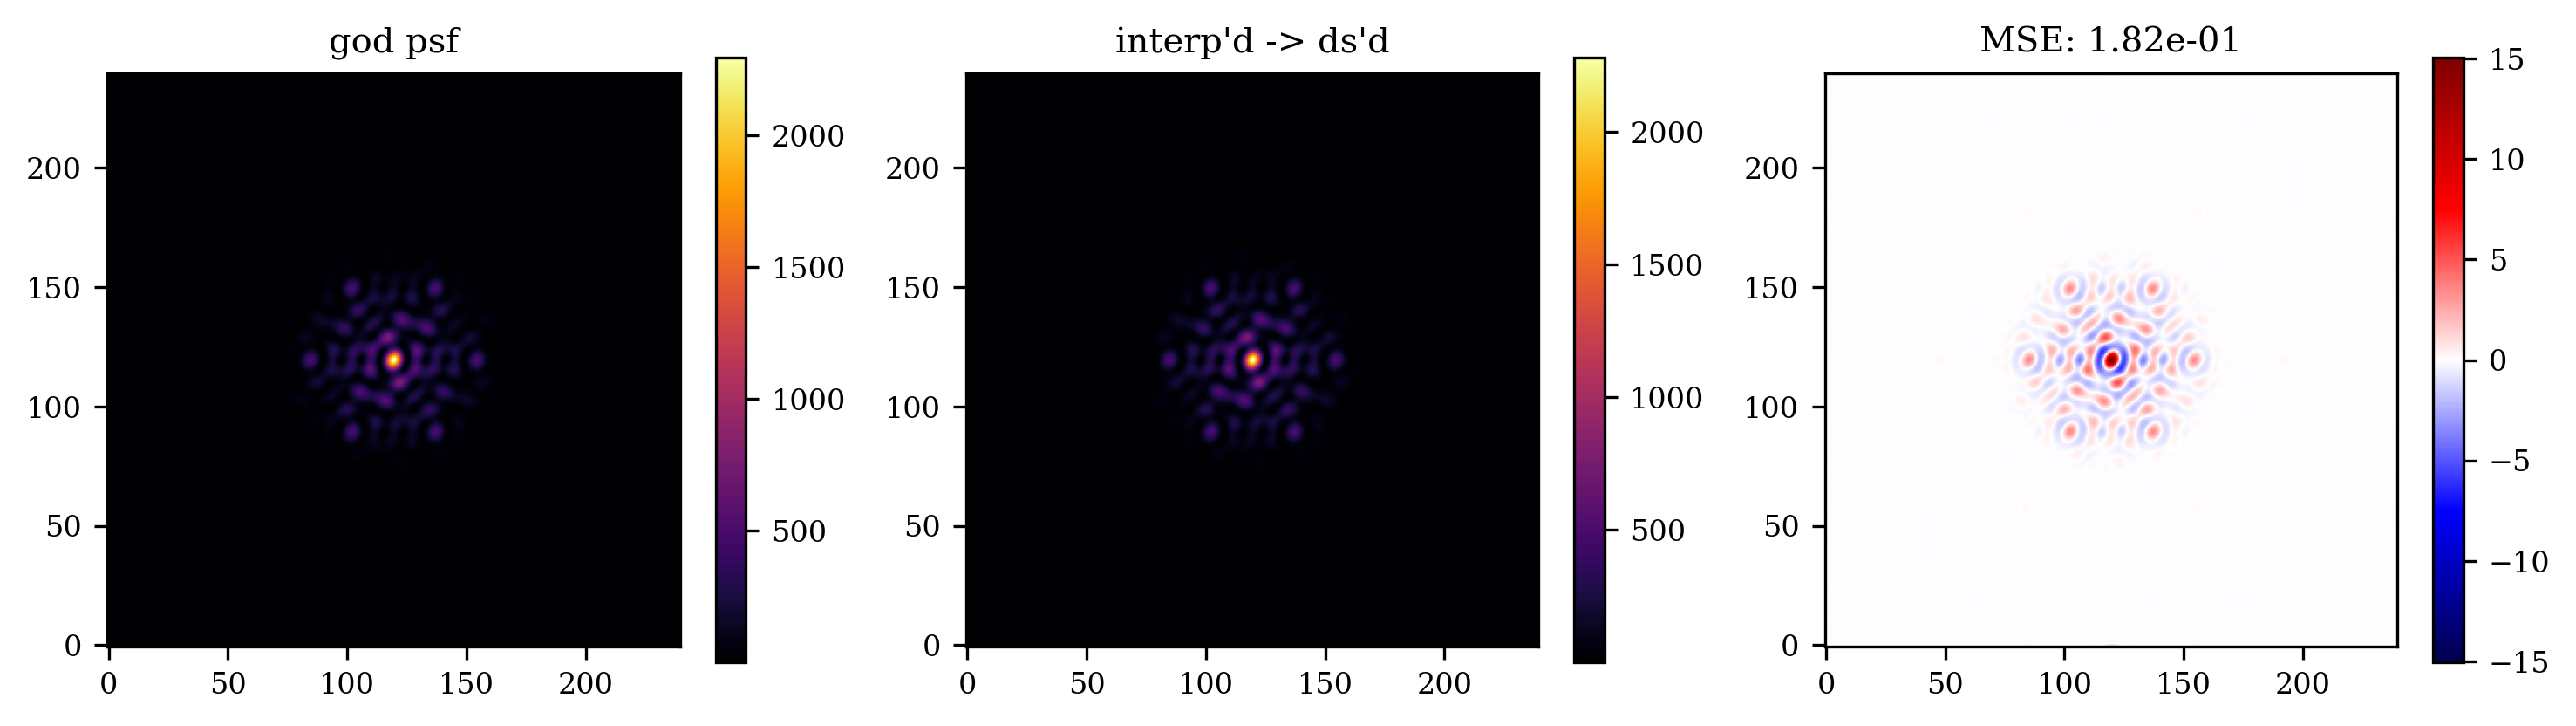

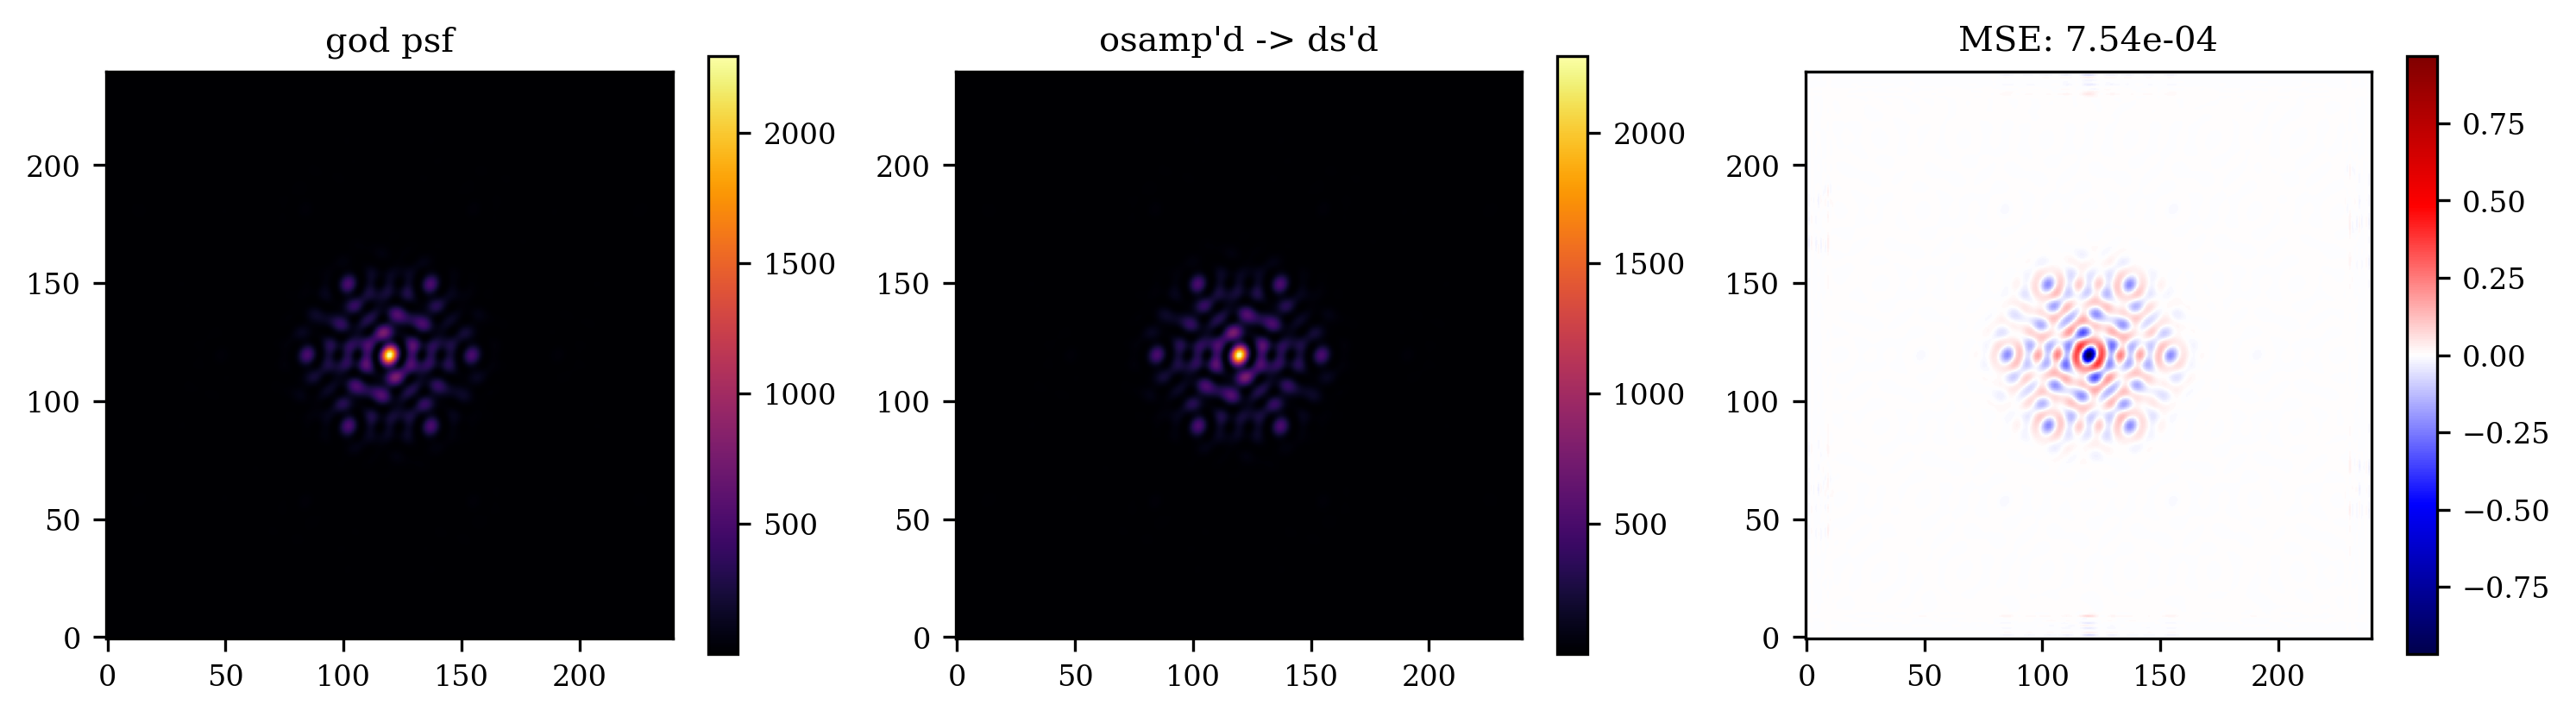

Filter: F430M, Oversampling: 3
(240, 240) (720, 720) (240, 240)


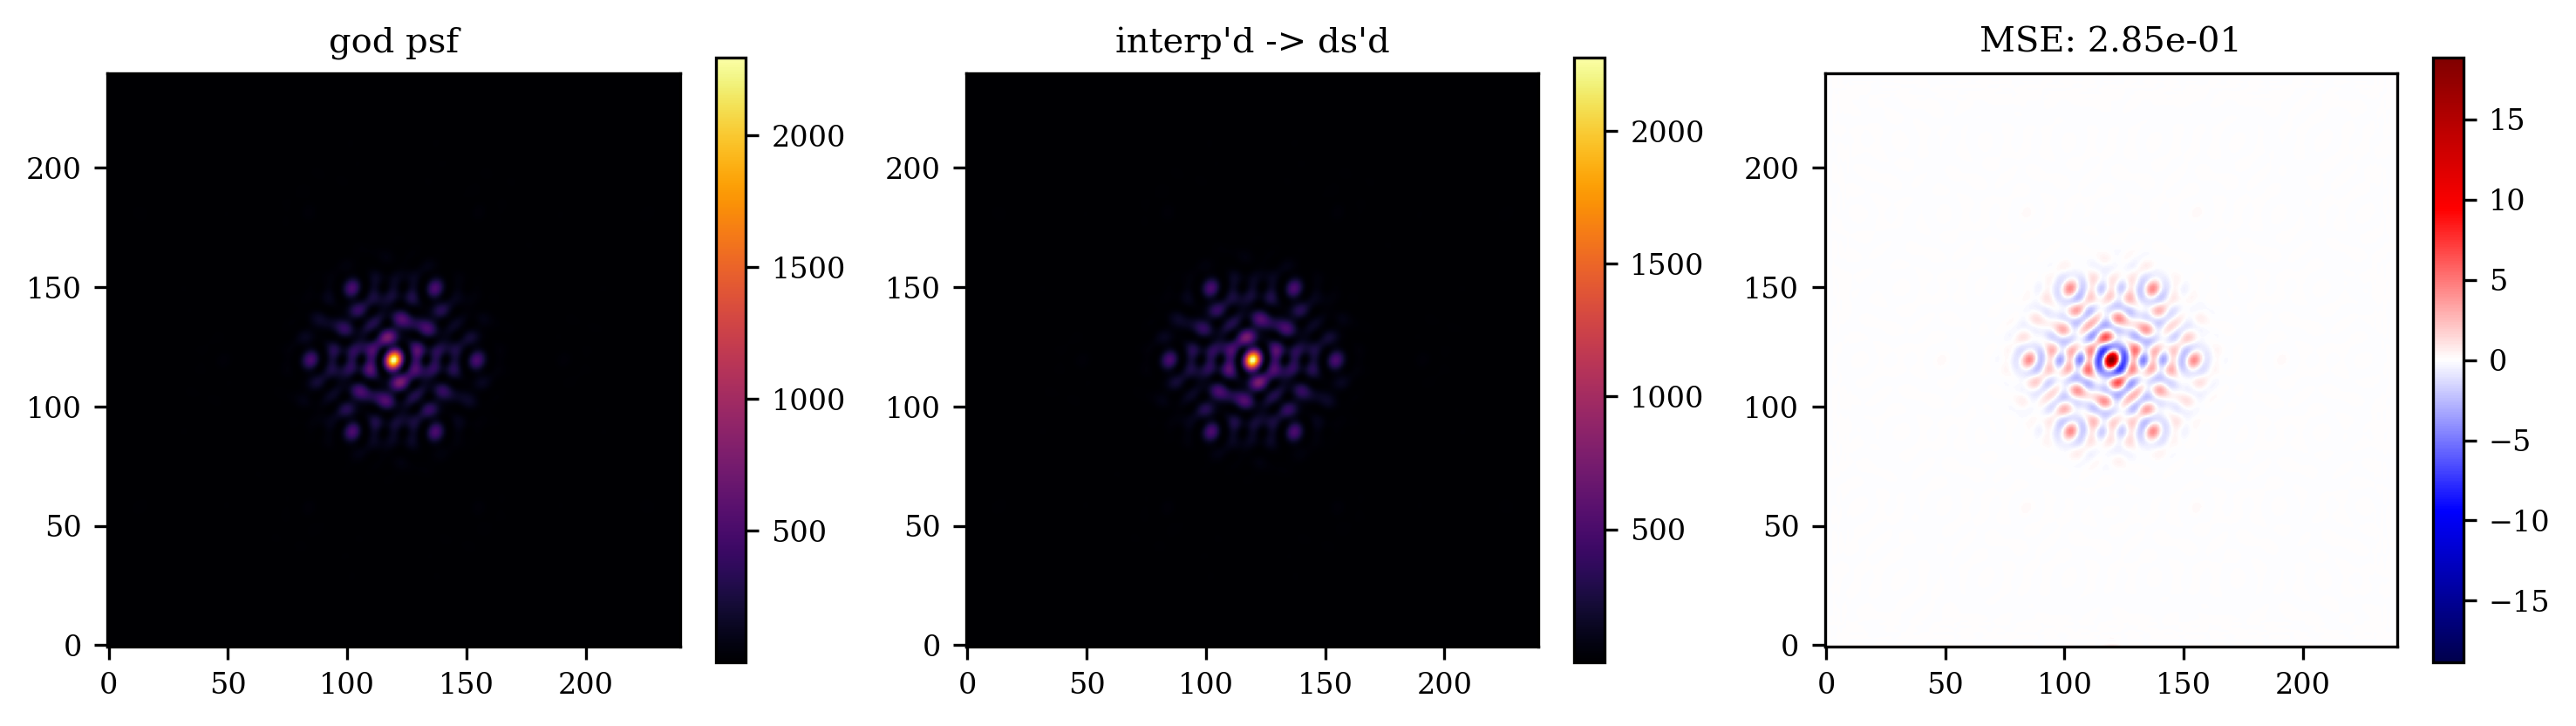

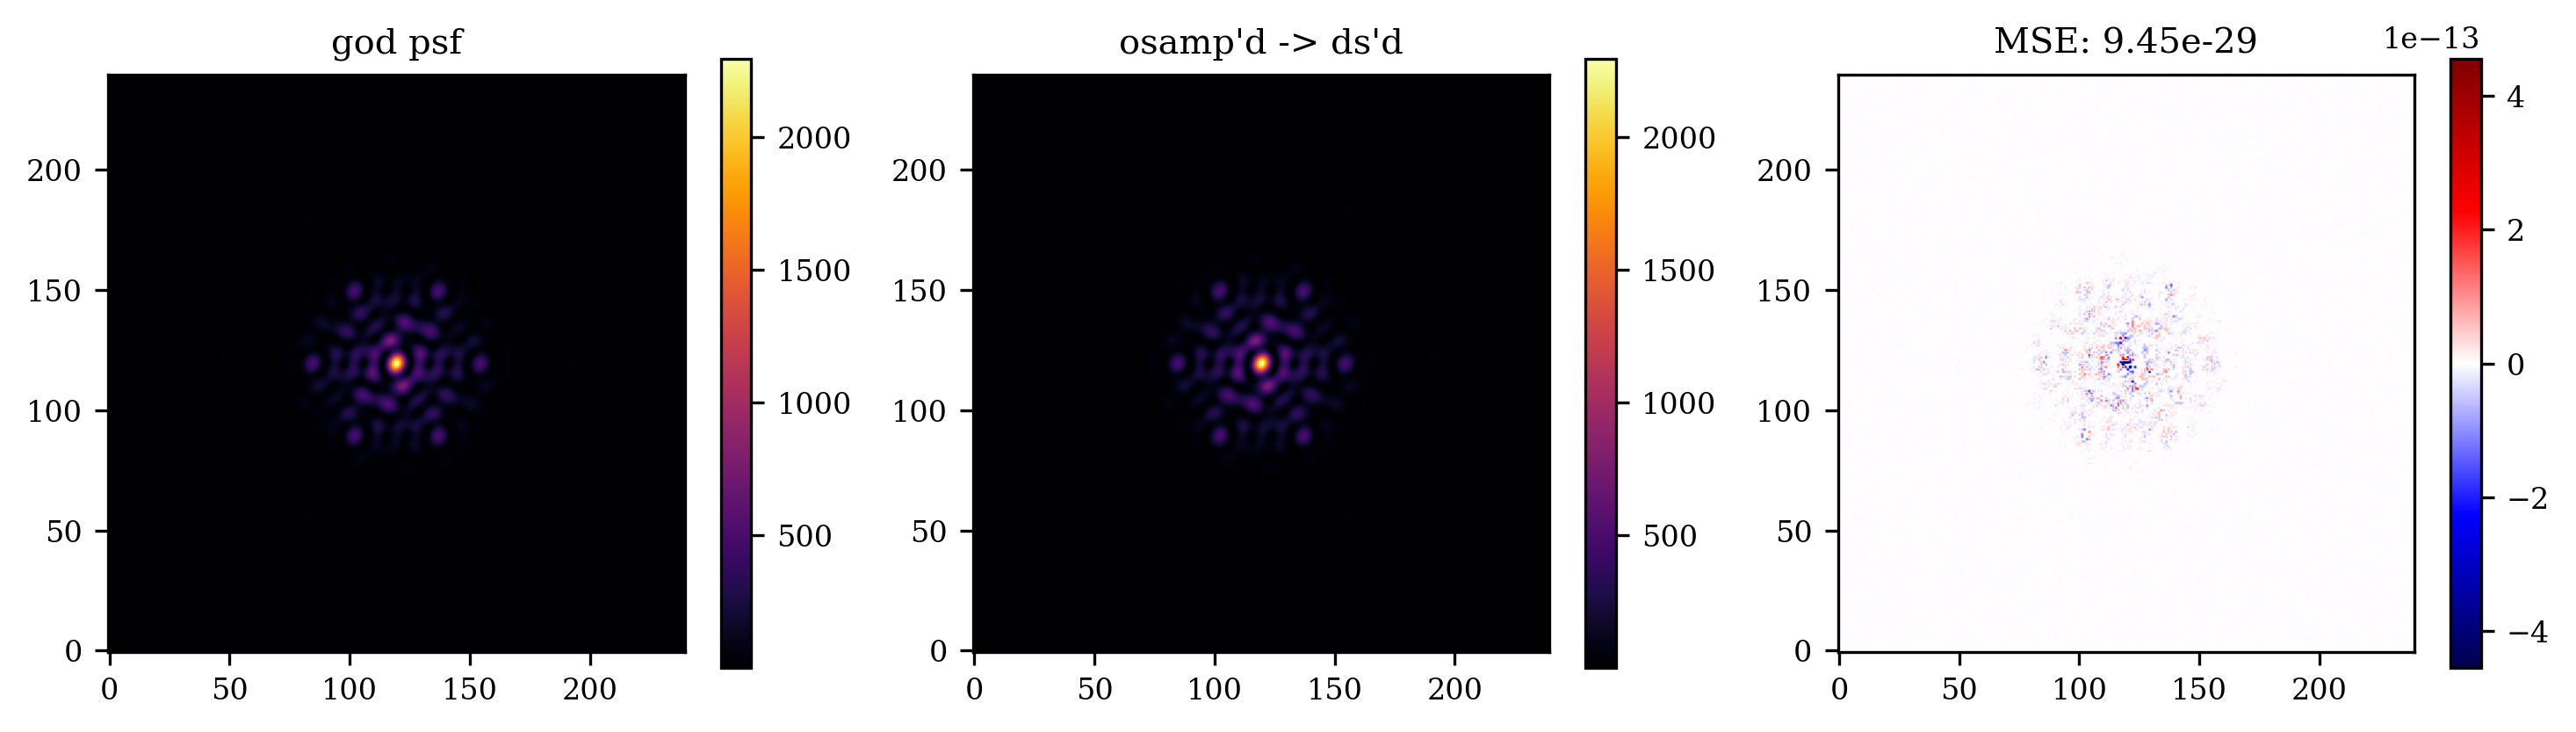

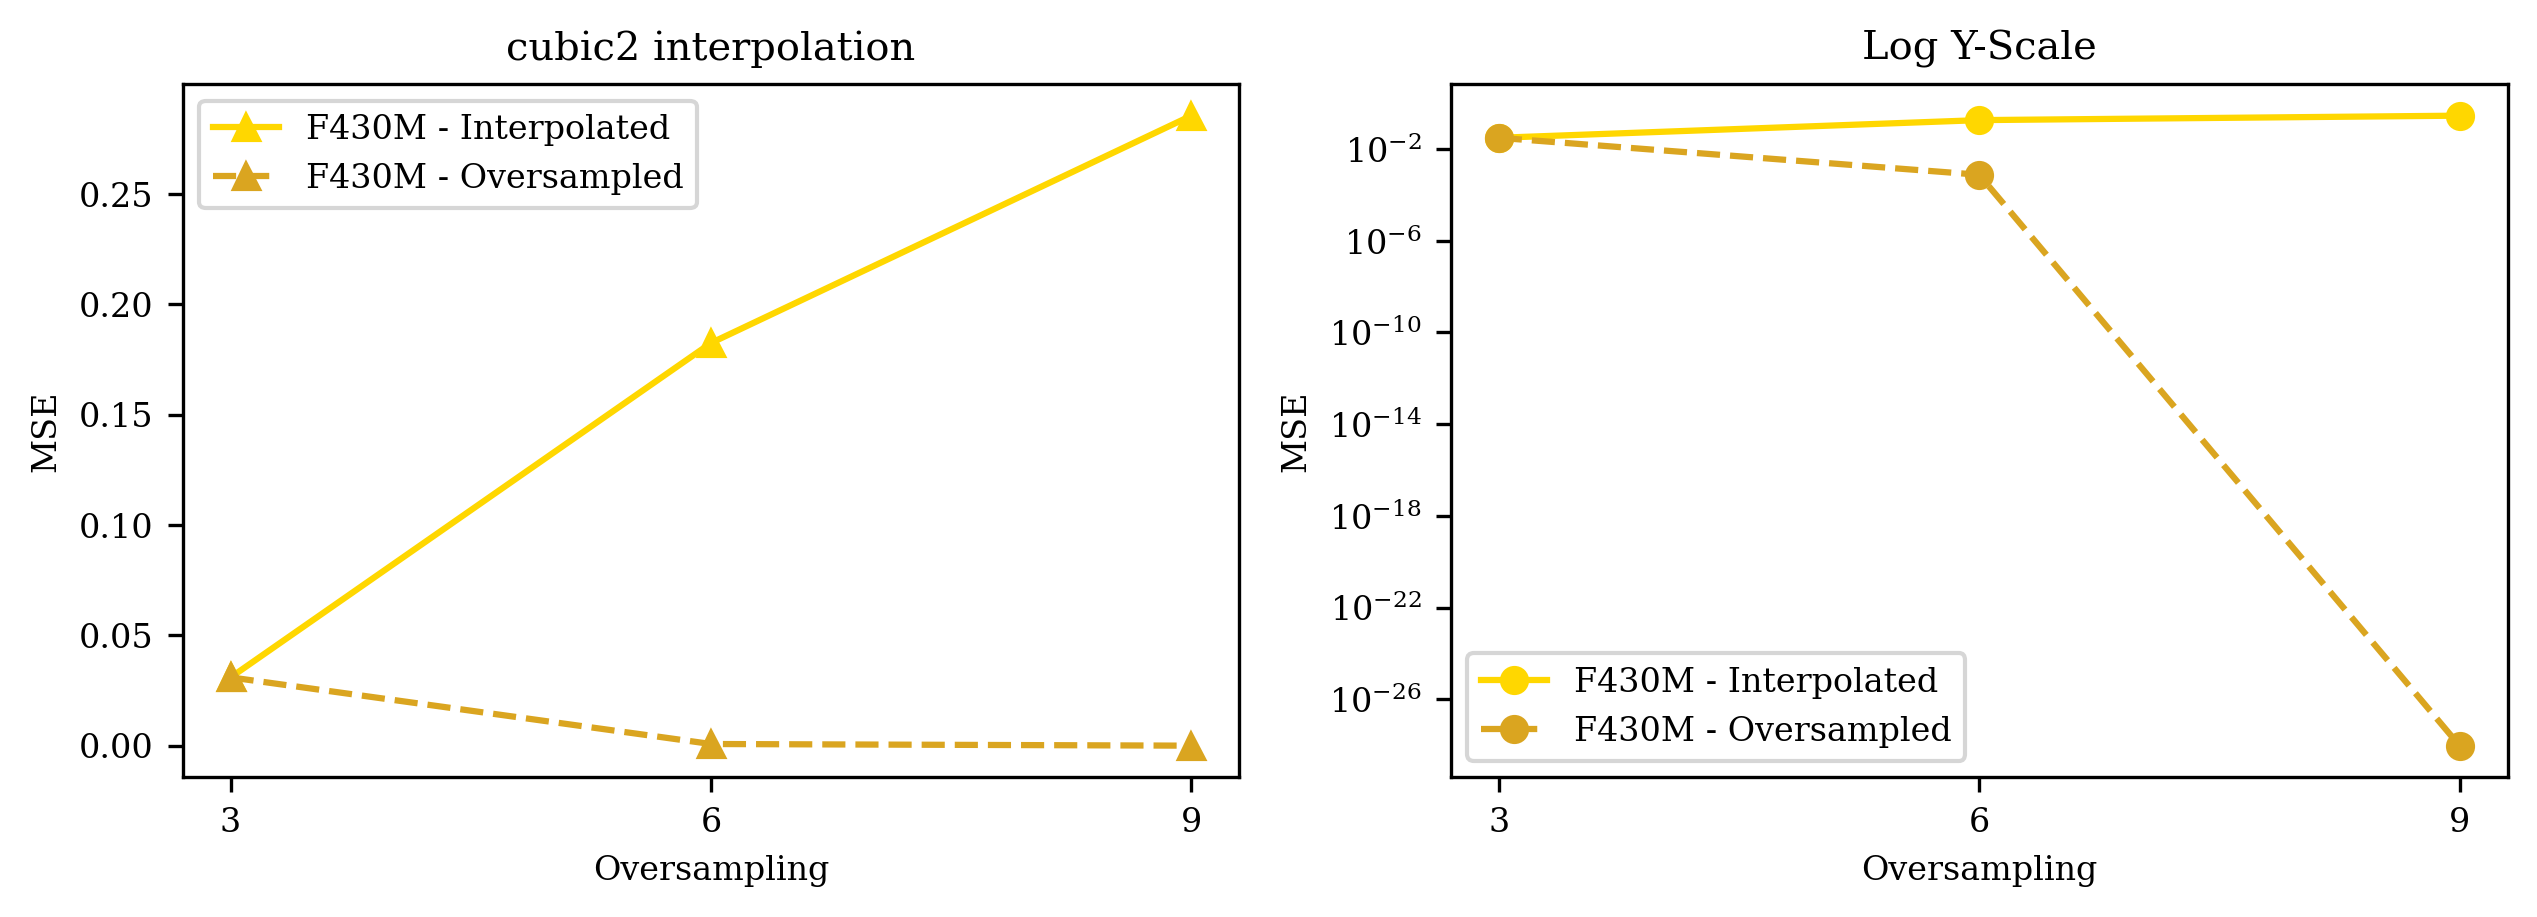

In [9]:
knots = dlu.pixel_coords(npixels=240, diameter=1.0)

FILTERS = [
    # "F380M",
    "F430M",
    # "F480M",
]
plot = True

interp_methods = [
    # "nearest",
    # "linear",
    # "cubic",
    "cubic2",
    # "catmull-rom",
    # "cardinal",
    # "monotonic",
    # "monotonic-0",
    # "akima",
]
mses = {}
mses_nointerp = {}
psfs = {}
for filter in FILTERS:
    # for filter in ["F430M"]:

    wavels, weights = model.filters[filter]
    psf = 1e6 * model.optics.propagate(wavels, weights=weights)
    psfs[filter] = psf

for method in interp_methods:
    for filter in FILTERS:
        # for filter in ["F430M"]:

        osamps = []
        mses_filt = []
        mses_nointerp_filt = []

        for i in range(1, god_given_osamp // 3 + 1):
            print(f"Filter: {filter}, Oversampling: {i}")
            osamps.append(3 * i)

            # INTERPOLATION ROUTINE
            sample_coords = dlu.pixel_coords(npixels=240 * i, diameter=1.0)
            scaled_psf = amigo.misc.interp(
                psfs[filter], knots, sample_coords, method=method
            )
            ds_psf = dlu.downsample(scaled_psf, i)

            mses_filt.append(np.mean((god_psfs[filter] - ds_psf) ** 2))

            # OPTICS OVERSAMPLE ROUTINE
            osamp_model = model.set("oversample", 3 * i)
            wavels, weights = model.filters[filter]
            osamp_psf = 1e6 * osamp_model.optics.propagate(wavels, weights=weights)
            osamp_psf = i * i * dlu.downsample(osamp_psf, i)

            mses_nointerp_filt.append(np.mean((god_psfs[filter] - osamp_psf) ** 2))

            if plot:
                print(psfs[filter].shape, scaled_psf.shape, ds_psf.shape)

                plt.figure(figsize=(12, 3))
                plt.subplot(1, 3, 1)
                plt.title("god psf")
                plt.imshow(god_psfs[filter])
                plt.colorbar()
                plt.subplot(1, 3, 2)
                plt.title("interp'd -> ds'd")
                plt.imshow(ds_psf)
                plt.colorbar()

                residuals = god_psfs[filter] - ds_psf
                plt.subplot(1, 3, 3)
                plt.imshow(residuals, seismic, norm=mpl.colors.CenteredNorm())
                plt.colorbar()
                plt.title(f"MSE: {mses_filt[-1]:.2e}")
                plt.show()

                plt.figure(figsize=(12, 3))
                plt.subplot(1, 3, 1)
                plt.title("god psf")
                plt.imshow(god_psfs[filter])
                plt.colorbar()
                plt.subplot(1, 3, 2)
                plt.title("osamp'd -> ds'd")
                plt.imshow(osamp_psf)
                plt.colorbar()

                residuals = god_psfs[filter] - osamp_psf
                plt.subplot(1, 3, 3)
                plt.imshow(residuals, seismic, norm=mpl.colors.CenteredNorm())
                plt.colorbar()
                plt.title(f"MSE: {mses_nointerp_filt[-1]:.2e}")
                plt.show()

        mses[filter] = mses_filt
        mses_nointerp[filter] = mses_nointerp_filt

    plt.figure(figsize=(10, 3))

    plt.subplot(1, 2, 1)
    plt.title(f"{method} interpolation")
    for filter, c in zip(
        # ["F430M"],
        FILTERS,
        [
            ("gold", "goldenrod"),
            ("royalblue", "dodgerblue"),
            ("orangered", "lightsalmon"),
        ],
    ):
        plt.plot(
            osamps,
            mses[filter],
            c=c[0],
            label=f"{filter} - Interpolated",
            marker="^",
        )
        plt.plot(
            osamps,
            mses_nointerp[filter],
            c=c[1],
            label=f"{filter} - Oversampled",
            linestyle="--",
            marker="^",
        )
    plt.xlabel("Oversampling")
    plt.ylabel("MSE")
    plt.xticks(osamps)
    plt.legend()

    plt.subplot(1, 2, 2)
    for filter, c, m in zip(
        # ["F430M"],
        FILTERS,
        [
            ("gold", "goldenrod"),
            ("royalblue", "dodgerblue"),
            ("orangered", "lightsalmon"),
        ],
        ["o", "s", "D"],
    ):

        plt.plot(
            osamps,
            mses[filter],
            c=c[0],
            label=f"{filter} - Interpolated",
            marker=m,
        )
        plt.plot(
            osamps,
            mses_nointerp[filter],
            c=c[1],
            label=f"{filter} - Oversampled",
            marker=m,
            linestyle="--",
        )
    plt.xlabel("Oversampling")
    plt.ylabel("MSE")
    plt.yscale("log")
    plt.title("Log Y-Scale")
    plt.xticks(osamps)
    plt.legend()
    plt.show()

TypeError: unhashable type: 'dict'

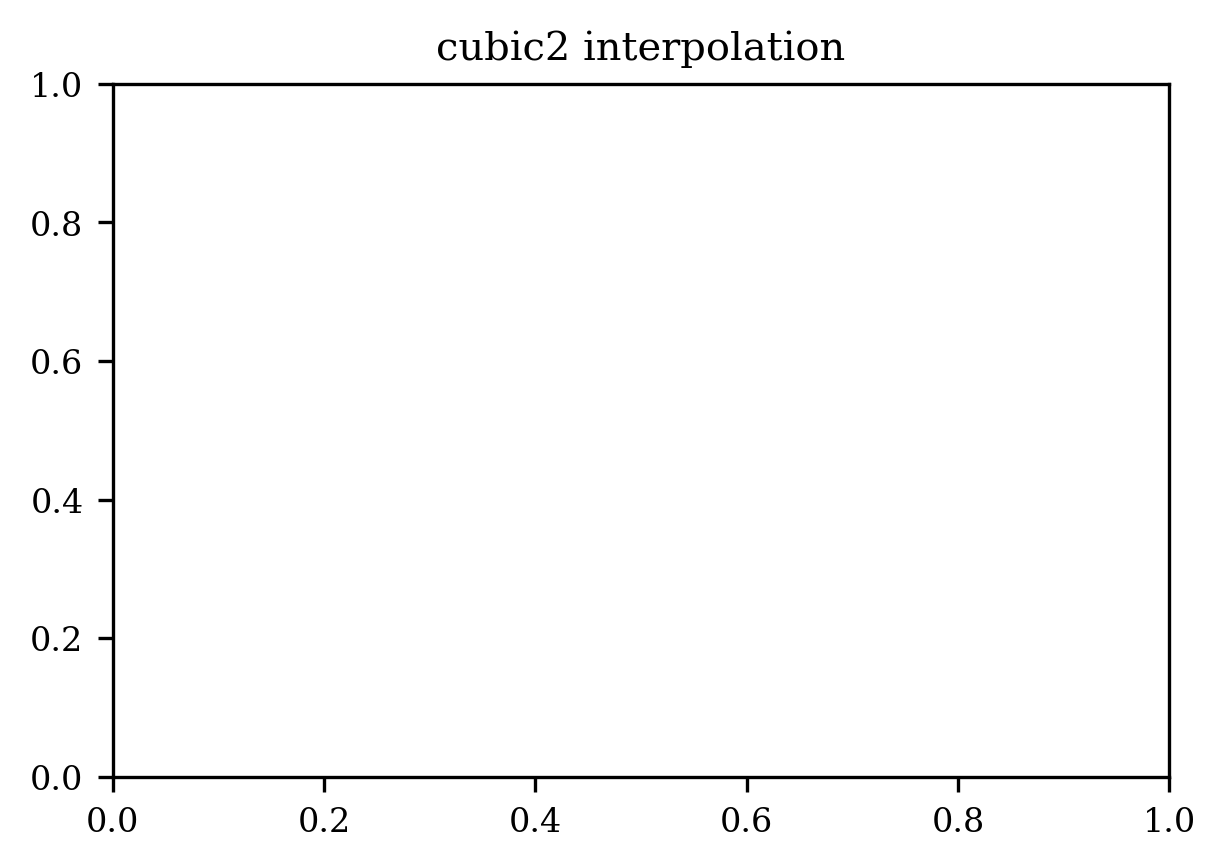

In [5]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.title(f"{method} interpolation")
plt.plot(osamps, mses, c="goldenrod", label="Interpolated", marker="^")
plt.plot(osamps, mses_nointerp, c="royalblue", label="No Interpolation", marker="^")
plt.xlabel("Oversampling")
plt.ylabel("MSE")
plt.xticks(osamps)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(osamps, mses, c="goldenrod", label="Interpolated", marker="^")
plt.plot(osamps, mses_nointerp, c="royalblue", label="No Interpolation", marker="^")
plt.xlabel("Oversampling")
plt.ylabel("MSE")
plt.yscale("log")
plt.xticks(osamps)
plt.legend()
plt.show()